In [76]:
import lightgbm as lgb

In [1]:
import gc
import json
import os
import random
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import spacy

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Memory helpers
try:
    import psutil
    HAS_PSUTIL = True
except ImportError:
    HAS_PSUTIL = False
    print("NOTE: psutil not installed. Memory monitoring disabled. Install: pip install psutil")

def mem_usage():
    if HAS_PSUTIL:
        process = psutil.Process()
        return process.memory_info().rss / 1024 / 1024
    return 0

def log_memory(tag=""):
    if HAS_PSUTIL:
        mb = mem_usage()
        print(f"[MEMORY {tag}] {mb:.1f} MB")
        return mb
    return 0

def cleanup():
    gc.collect()
    log_memory("after cleanup")

log_memory("start")

# %%
train = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/train.csv')
test = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/test.csv')
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
print(f"Train columns: {list(train.columns)}")
print(f"Test columns: {list(test.columns)}")


[MEMORY start] 372.3 MB
Train shape: (14397, 4), Test shape: (3603, 3)
Train columns: ['id', 'title', 'content', 'label']
Test columns: ['id', 'title', 'content']


In [2]:
label_names = {0: 'Tidak Sesuai', 1: 'Sesuai'}

def dataset_inspection(df, name="dataset"):
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nDtypes:\n{df.dtypes.to_string()}")
    print(f"\nMissing values:\n{df.isnull().sum().to_string()}")
    for col in df.select_dtypes(include='object').columns:
        empty_count = (df[col].astype(str).str.strip() == '').sum()
        print(f"Empty strings in '{col}': {empty_count}")
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    print()

dataset_inspection(train, "Train")
dataset_inspection(test, "Test")

# Auto-discover text columns & label
text_cols = [c for c in train.columns if train[c].dtype == 'object' and c != 'id']
label_col = [c for c in train.columns if c not in text_cols and c != 'id'][0]

headline_col = text_cols[0]
article_col = text_cols[1]
print(f"Auto-discovered: headline='{headline_col}', article='{article_col}', label='{label_col}'")

print(f"\nUnique labels: {train[label_col].unique()}")
print(f"\nLabel counts:")
print(train[label_col].value_counts().to_string())
print(f"\nLabel proportions:")
print(train[label_col].value_counts(normalize=True).to_string())


  Train
Shape: (14397, 4)

Columns: ['id', 'title', 'content', 'label']

Dtypes:
id         object
title      object
content    object
label       int64

Missing values:
id         0
title      0
content    0
label      0
Empty strings in 'id': 0
Empty strings in 'title': 0
Empty strings in 'content': 0

Duplicate rows: 0

  Test
Shape: (3603, 3)

Columns: ['id', 'title', 'content']

Dtypes:
id         object
title      object
content    object

Missing values:
id         0
title      0
content    0
Empty strings in 'id': 0
Empty strings in 'title': 0
Empty strings in 'content': 0

Duplicate rows: 0

Auto-discovered: headline='title', article='content', label='label'

Unique labels: [0 1]

Label counts:
label
1    12960
0     1437

Label proportions:
label
1    0.900188
0    0.099812


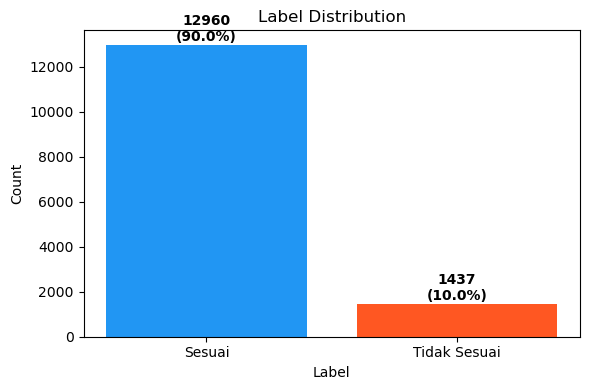


Imbalance ratio: 9.02:1
Majority baseline accuracy: 90.0%


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
label_counts = train[label_col].value_counts()
display_names = [label_names.get(int(l), str(l)) for l in label_counts.index]

bars = ax.bar(display_names, label_counts.values, color=['#2196F3', '#FF5722'])
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{count}\n({count/len(train)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Label Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Majority baseline accuracy: {label_counts.max()/len(train)*100:.1f}%")


=== Text Length Statistics ===

headline_char_len:
  mean=63.8, median=62.0, min=17, max=150, std=11.0

headline_word_len:
  mean=10.1, median=10.0, min=3, max=23, std=2.0

article_char_len:
  mean=2126.8, median=1893.0, min=16, max=31584, std=1200.2

article_word_len:
  mean=309.9, median=276.0, min=3, max=4238, std=169.6


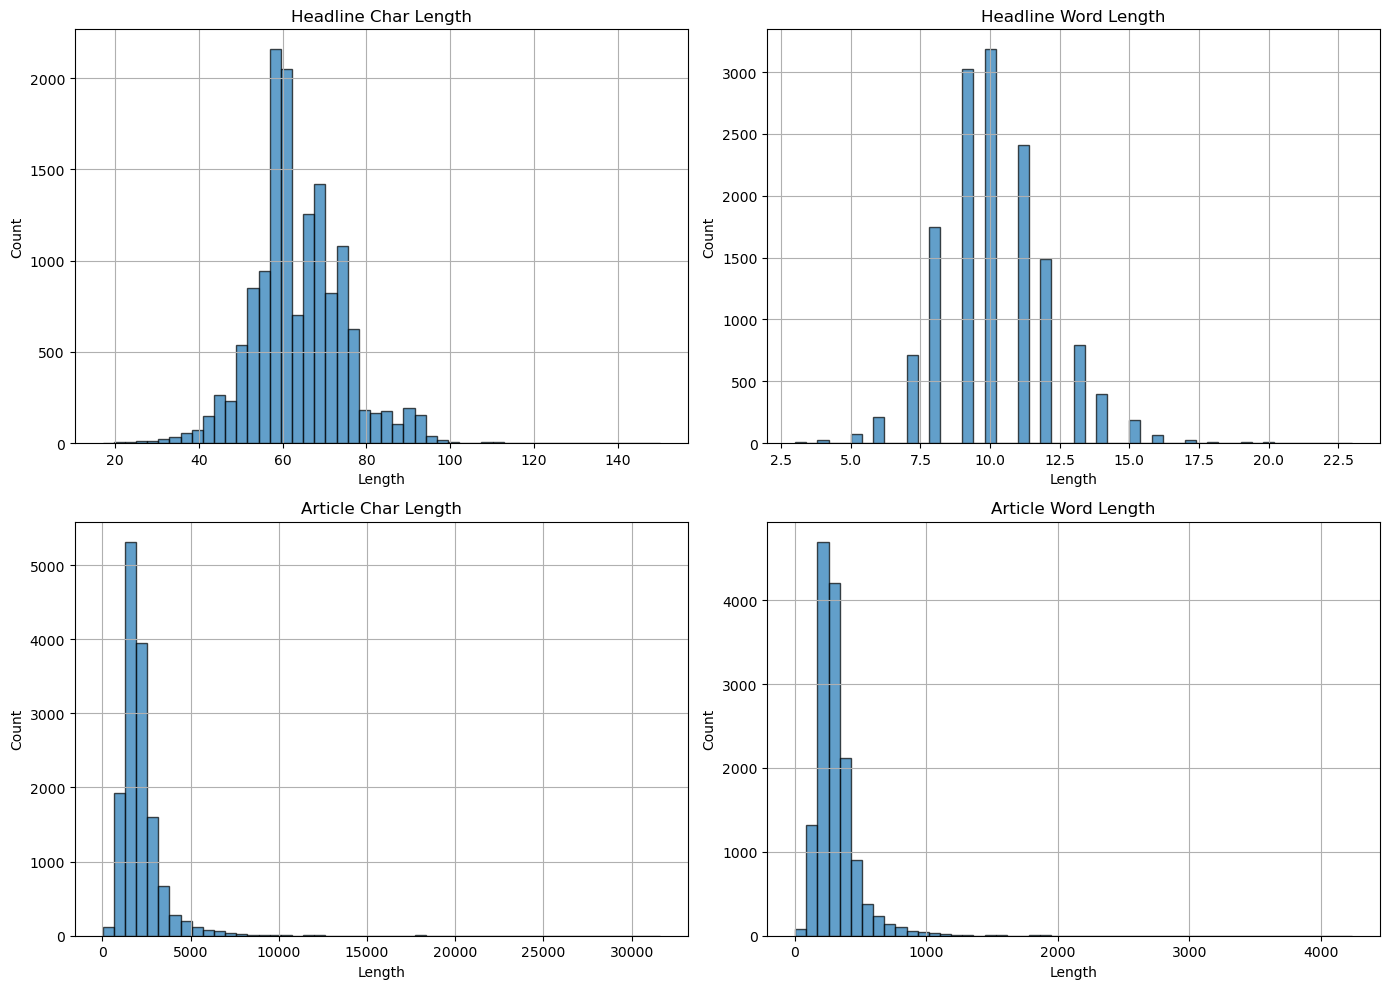

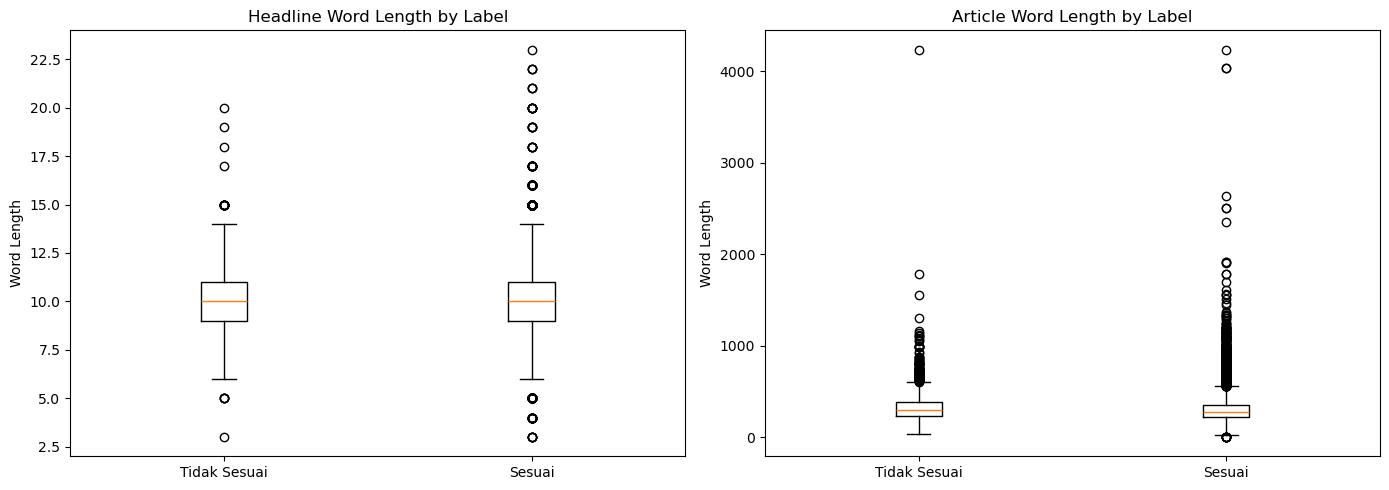


=== Outlier Analysis (IQR Method) ===
headline outliers: 415 (2.88%)
article outliers: 796 (5.53%)


In [4]:
def compute_text_lengths(df, col, prefix):
    df = df.copy()
    df[f'{prefix}_char_len'] = df[col].astype(str).str.len()
    df[f'{prefix}_word_len'] = df[col].astype(str).apply(lambda x: len(x.split()))
    return df

train = compute_text_lengths(train, headline_col, 'headline')
train = compute_text_lengths(train, article_col, 'article')

print("=== Text Length Statistics ===")
for metric in ['headline_char_len', 'headline_word_len', 'article_char_len', 'article_word_len']:
    s = train[metric]
    print(f"\n{metric}:")
    print(f"  mean={s.mean():.1f}, median={s.median():.1f}, min={s.min()}, max={s.max()}, std={s.std():.1f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, title in zip(axes.flat,
    ['headline_char_len', 'headline_word_len', 'article_char_len', 'article_word_len'],
    ['Headline Char Length', 'Headline Word Length', 'Article Char Length', 'Article Word Length']):
    train[col].hist(bins=50, ax=ax, alpha=0.7, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Length')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, prefix, title in zip(axes, ['headline', 'article'], ['Headline', 'Article']):
    data_to_plot = [train[train[label_col] == lbl][f'{prefix}_word_len'] for lbl in sorted(train[label_col].unique())]
    ax.boxplot(data_to_plot, labels=[label_names.get(int(l), str(l)) for l in sorted(train[label_col].unique())])
    ax.set_title(f'{title} Word Length by Label')
    ax.set_ylabel('Word Length')
plt.tight_layout()
plt.show()

print("\n=== Outlier Analysis (IQR Method) ===")
for prefix in ['headline', 'article']:
    col_name = f'{prefix}_word_len'
    q1, q3 = train[col_name].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = train[(train[col_name] < lower) | (train[col_name] > upper)]
    print(f"{prefix} outliers: {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)")


In [5]:
def get_top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None)
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    return words_freq

for n, label_n in [(1, 'unigram'), (2, 'bigram')]:
    print(f"\n{'='*50}")
    print(f"  Top {label_n.upper()} (Global)")
    print(f"{'='*50}")
    for text_col, text_name in [(headline_col, 'Headline'), (article_col, 'Article')]:
        top = get_top_ngrams(train[text_col].astype(str), n=n, top_k=15)
        print(f"\n  {text_name}:")
        for word, freq in top:
            print(f"    {word}: {freq}")

for lbl in sorted(train[label_col].unique()):
    subset = train[train[label_col] == lbl]
    lbl_name = label_names.get(int(lbl), str(lbl))
    print(f"\n{'='*50}")
    print(f"  Label: {lbl_name} ({lbl})")
    print(f"{'='*50}")
    for n, label_n in [(1, 'unigram'), (2, 'bigram')]:
        for text_col, text_name in [(headline_col, 'Headline'), (article_col, 'Article')]:
            top = get_top_ngrams(subset[text_col].astype(str), n=n, top_k=10)
            print(f"\n  Top {label_n} ({text_name}):")
            for word, freq in top:
                print(f"    {word}: {freq}")



  Top UNIGRAM (Global)

  Headline:
    di: 4287
    corona: 4255
    covid: 4046
    19: 3251
    positif: 1771
    kasus: 1747
    vaksin: 1101
    ini: 1001
    dan: 995
    tak: 880
    baru: 877
    kumparan: 874
    com: 874
    yang: 712
    dki: 691

  Article:
    yang: 97657
    di: 91852
    dan: 78158
    19: 49526
    covid: 49153
    ini: 47704
    dari: 43823
    untuk: 39567
    itu: 37190
    dengan: 35555
    kasus: 32514
    dalam: 30397
    pada: 26640
    ada: 25698
    tidak: 25052

  Top BIGRAM (Global)

  Headline:
    covid 19: 3175
    kumparan com: 874
    positif covid: 780
    positif corona: 667
    corona di: 578
    19 di: 491
    kasus corona: 411
    vaksin corona: 373
    vaksin covid: 306
    kasus covid: 304
    pasien covid: 256
    update corona: 251
    virus corona: 247
    habib rizieq: 245
    zona merah: 243

  Article:
    covid 19: 46871
    virus corona: 12222
    protokol kesehatan: 7903
    saat ini: 7203
    19 di: 6653
    hari ini: 5

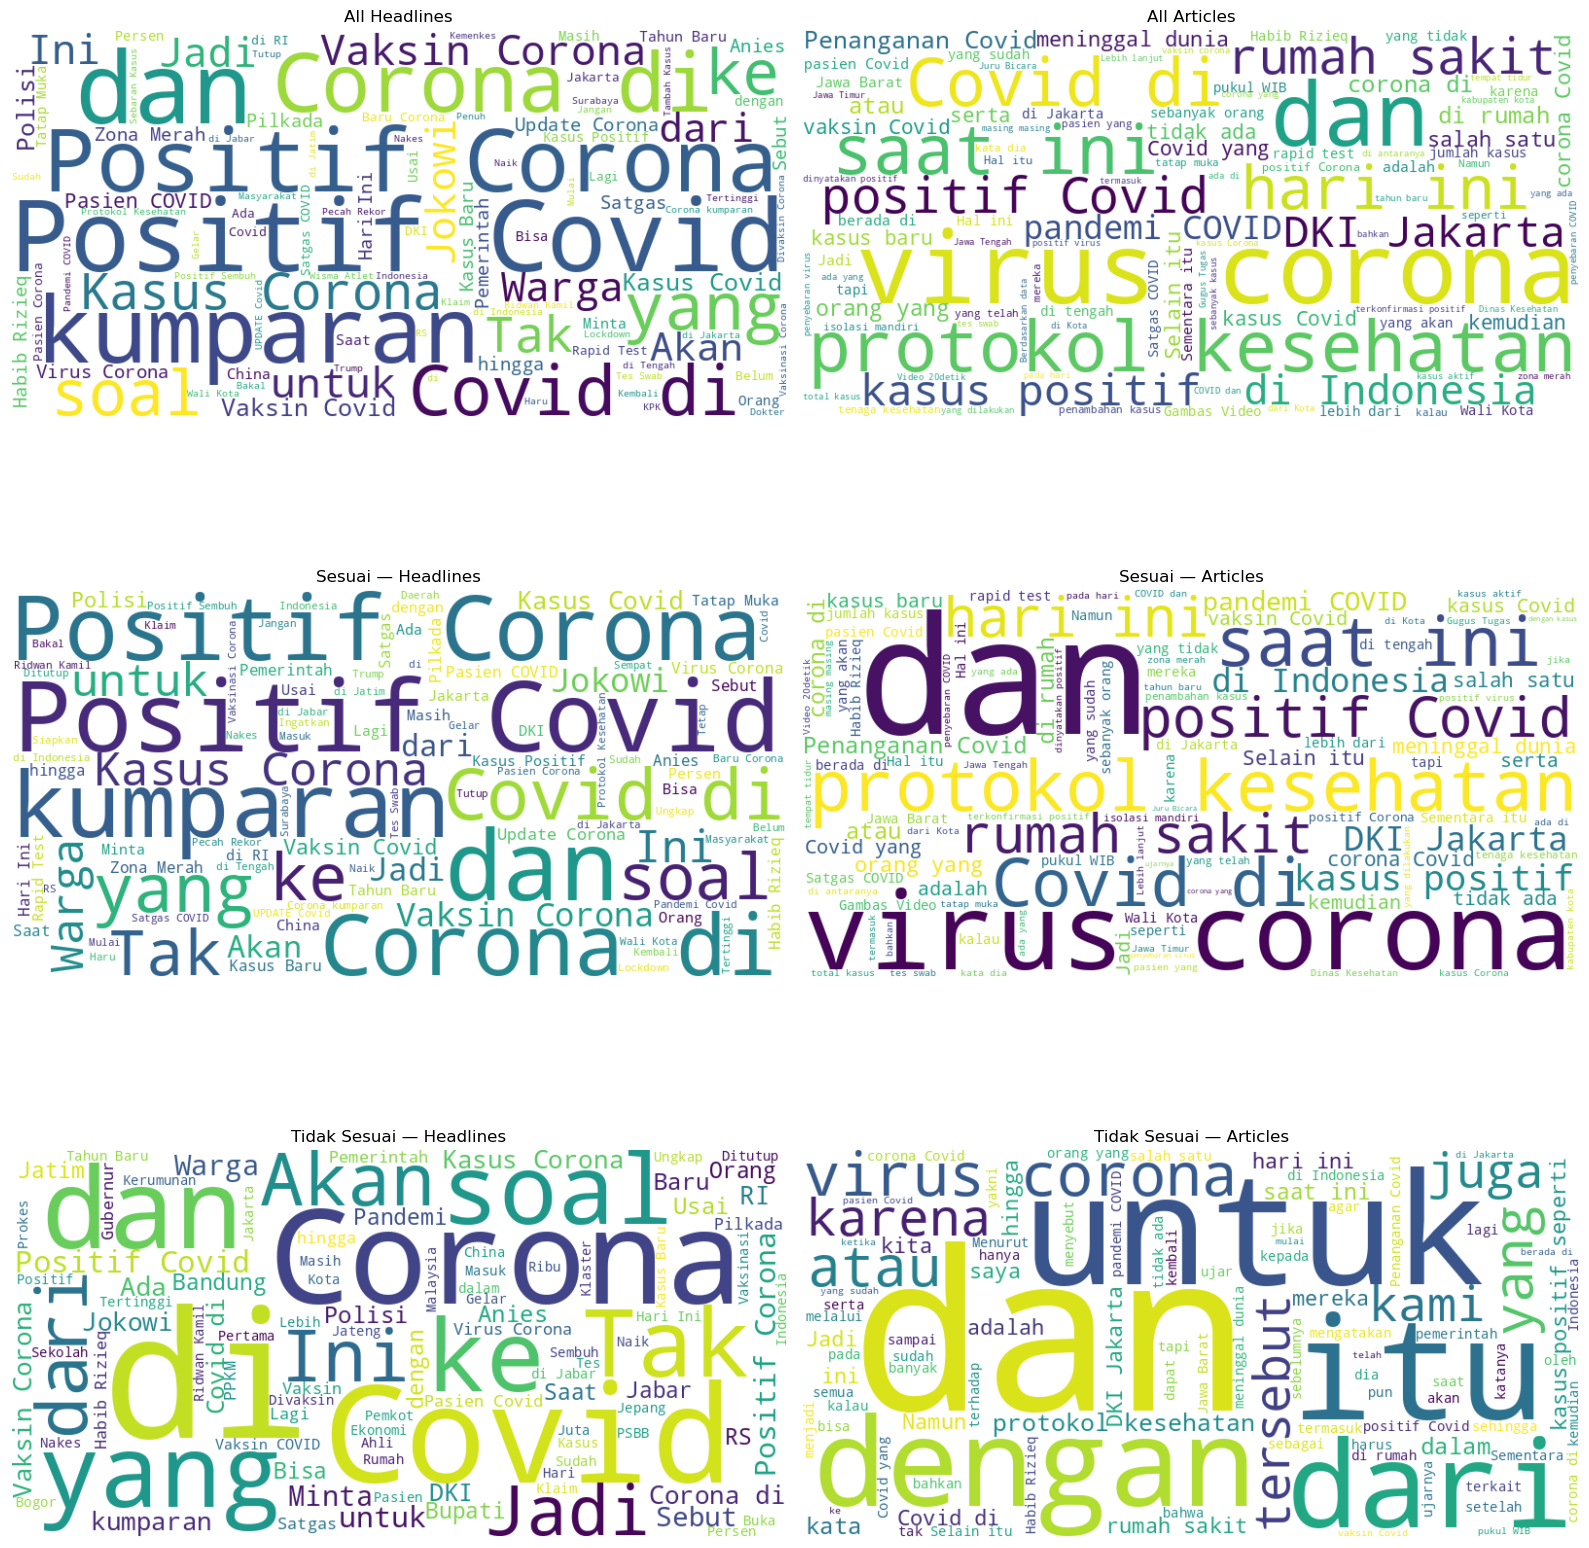

In [6]:
def create_wordcloud(corpus, title, ax):
    text = ' '.join(corpus.astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
corpora = [
    (train[headline_col], 'All Headlines'),
    (train[article_col], 'All Articles'),
    (train[train[label_col]==1][headline_col], 'Sesuai — Headlines'),
    (train[train[label_col]==1][article_col], 'Sesuai — Articles'),
    (train[train[label_col]==0][headline_col], 'Tidak Sesuai — Headlines'),
    (train[train[label_col]==0][article_col], 'Tidak Sesuai — Articles'),
]
for ax, (corpus, title) in zip(axes.flat, corpora):
    create_wordcloud(corpus, title, ax)
plt.tight_layout()
plt.show()


In [7]:
with open('../data/external/wordlists.json', 'r', encoding='utf-8') as f:
    WORDLISTS = json.load(f)

print("Wordlists loaded:")
for k, v in WORDLISTS.items():
    print(f"  {k}: {len(v)} items")

# Load InSet lexicon
SENTIMENT_LEXICON = {}

for sentiment_file, sign in [
    (r'E:\GRINDING\DATA SCIENCE\IFEST_2026\inset_lexicon\InSet\positive.tsv', 1),
    (r'E:\GRINDING\DATA SCIENCE\IFEST_2026\inset_lexicon\InSet\negative.tsv', -1),
]:
    with open(sentiment_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i == 0:  # skip header
                continue
            parts = line.strip().split('\t')
            if len(parts) == 2:
                word, weight = parts[0].strip(), int(parts[1].strip())
                SENTIMENT_LEXICON[word] = weight

print(f"\nSentiment lexicon loaded: {len(SENTIMENT_LEXICON)} words")
print(f"  Positive: {sum(1 for v in SENTIMENT_LEXICON.values() if v > 0)}")
print(f"  Negative: {sum(1 for v in SENTIMENT_LEXICON.values() if v < 0)}")
print(f"  Weight range: [{min(SENTIMENT_LEXICON.values())}, {max(SENTIMENT_LEXICON.values())}]")


Wordlists loaded:
  action_verbs: 240 items
  superlatives: 54 items
  discourse_markers: 21 items
  negation_words: 12 items
  buzzwords: 32 items
  month_names: 12 items

Sentiment lexicon loaded: 9074 words
  Positive: 2467
  Negative: 6607
  Weight range: [-5, 5]


In [10]:
import re
import spacy
from sklearn.base import BaseEstimator, TransformerMixin
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


# Stopwords
stop_factory = StopWordRemoverFactory()
STOP_WORDS = set(stop_factory.get_stop_words())

# Create spaCy tokenizer ONCE
nlp = spacy.blank("id")


class TextPreprocessor(BaseEstimator, TransformerMixin):
    """
    Stateless text preprocessor.
    Outputs:
        - clean_a: light cleaning
        - clean_b: lowercase + stopword removal
        - tokens: spaCy tokenization
    """

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for col in [headline_col, article_col]:

            # Step 1-4: Light cleaning
            X[f'{col}_clean_a'] = (
                X[col]
                .astype(str)
                .apply(self._light_clean)
            )

            # Step 5: Lowercase + stopword removal
            X[f'{col}_clean_b'] = (
                X[f'{col}_clean_a']
                .apply(self._normalize)
            )

            # Step 6: Tokenization
            X[f'{col}_tokens'] = (
                X[f'{col}_clean_b']
                .apply(self._tokenize)
            )

        return X

    @staticmethod
    def _light_clean(text):
        text = re.sub(r'\s+', ' ', str(text)).strip()
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'\S+@\S+', '', text)
        text = re.sub(r'[^\w\s.,;:!?%$()\-/+]', '', text)

        return text

    @staticmethod
    def _remove_stopwords(text):
        words = str(text).split()

        return ' '.join(
            w for w in words
            if w not in STOP_WORDS
        )

    def _normalize(self, text):
        text = str(text).lower()
        text = self._remove_stopwords(text)

        return text

    @staticmethod
    def _tokenize(text):
        doc = nlp(str(text))
        return [token.text for token in doc]

In [11]:
print("=== Applying TextPreprocessor ===")
t0 = time.time()

preprocessor = TextPreprocessor()

# Fit and transform train
train = preprocessor.fit_transform(train)
print(f"  Train: {train.shape}")

# Transform only test (no fit!)
test = preprocessor.transform(test)
print(f"  Test: {test.shape}")

print(f"\nNew columns: {[c for c in train.columns if 'clean' in c or 'tokens' in c]}")
print(f"Time: {time.time()-t0:.1f}s")

# Verify
print(f"\nSample headline_clean_a: {train[f'{headline_col}_clean_a'].iloc[0][:100]}...")
print(f"Sample headline_clean_b: {train[f'{headline_col}_clean_b'].iloc[0][:100]}...")
print(f"Sample headline_tokens: {train[f'{headline_col}_tokens'].iloc[0][:10]}")

cleanup()


=== Applying TextPreprocessor ===
  Train: (14397, 14)
  Test: (3603, 9)

New columns: ['title_clean_a', 'title_clean_b', 'title_tokens', 'content_clean_a', 'content_clean_b', 'content_tokens']
Time: 30.1s

Sample headline_clean_a: Tak Lagi Jadi Jubir Yurianto Tak Umumkan Update Harian Covid...
Sample headline_clean_b: tak jadi jubir yurianto tak umumkan update harian covid...
Sample headline_tokens: ['tak', 'jadi', 'jubir', 'yurianto', 'tak', 'umumkan', 'update', 'harian', 'covid']
[MEMORY after cleanup] 689.9 MB


In [12]:
interim_dir = '../data/interim'
os.makedirs(interim_dir, exist_ok=True)

processing_log = {
    "created_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
    "source": "../data/raw/penyisihan-dac-ifest-2026/train.csv",
    "total_rows": int(len(train)),
    "columns_processed": [headline_col, article_col],
    "variants": {}
}

# Save each variant
for variant_suffix, variant_name, cols in [
    ('clean_a', 'A_light', [headline_col, article_col]),
    ('clean_b', 'B_normalized', [headline_col, article_col]),
]:
    save_cols = ['id', label_col] + [f'{c}_{variant_suffix}' for c in cols]
    save_df = train[save_cols].copy()

    save_path = os.path.join(interim_dir, f'train_{variant_suffix}.csv')
    save_df.to_csv(save_path, index=False)

    processing_log['variants'][variant_name] = {
        "file": save_path,
        "rows": int(len(save_df)),
    }
    print(f"  Saved {save_path}")

# Save tokens
tokens_df = train[['id', label_col, f'{headline_col}_tokens', f'{article_col}_tokens']].copy()
tokens_df.to_csv(os.path.join(interim_dir, 'train_tokens.csv'), index=False)
print(f"  Saved train_tokens.csv")

# Save raw as reference
train[['id', label_col, headline_col, article_col]].to_csv(os.path.join(interim_dir, 'train_raw.csv'), index=False)
print(f"  Saved train_raw.csv")

# Save metadata
with open(os.path.join(interim_dir, 'processing_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(processing_log, f, indent=2, ensure_ascii=False)
print(f"  Saved processing_metadata.json")


  Saved ../data/interim\train_clean_a.csv
  Saved ../data/interim\train_clean_b.csv
  Saved train_tokens.csv
  Saved train_raw.csv
  Saved processing_metadata.json



=== Lexical Overlap: A: Light ===

  jaccard:
    Tidak Sesuai: mean=0.0453, median=0.0424
    Sesuai: mean=0.0519, median=0.0481

  overlap_coeff:
    Tidak Sesuai: mean=0.7494, median=0.7500
    Sesuai: mean=0.7957, median=0.8000

  dice:
    Tidak Sesuai: mean=0.0859, median=0.0814
    Sesuai: mean=0.0978, median=0.0918

=== Lexical Overlap: B: Normalized ===

  jaccard:
    Tidak Sesuai: mean=0.0476, median=0.0444
    Sesuai: mean=0.0560, median=0.0517

  overlap_coeff:
    Tidak Sesuai: mean=0.7295, median=0.7273
    Sesuai: mean=0.7851, median=0.8000

  dice:
    Tidak Sesuai: mean=0.0900, median=0.0851
    Sesuai: mean=0.1049, median=0.0984


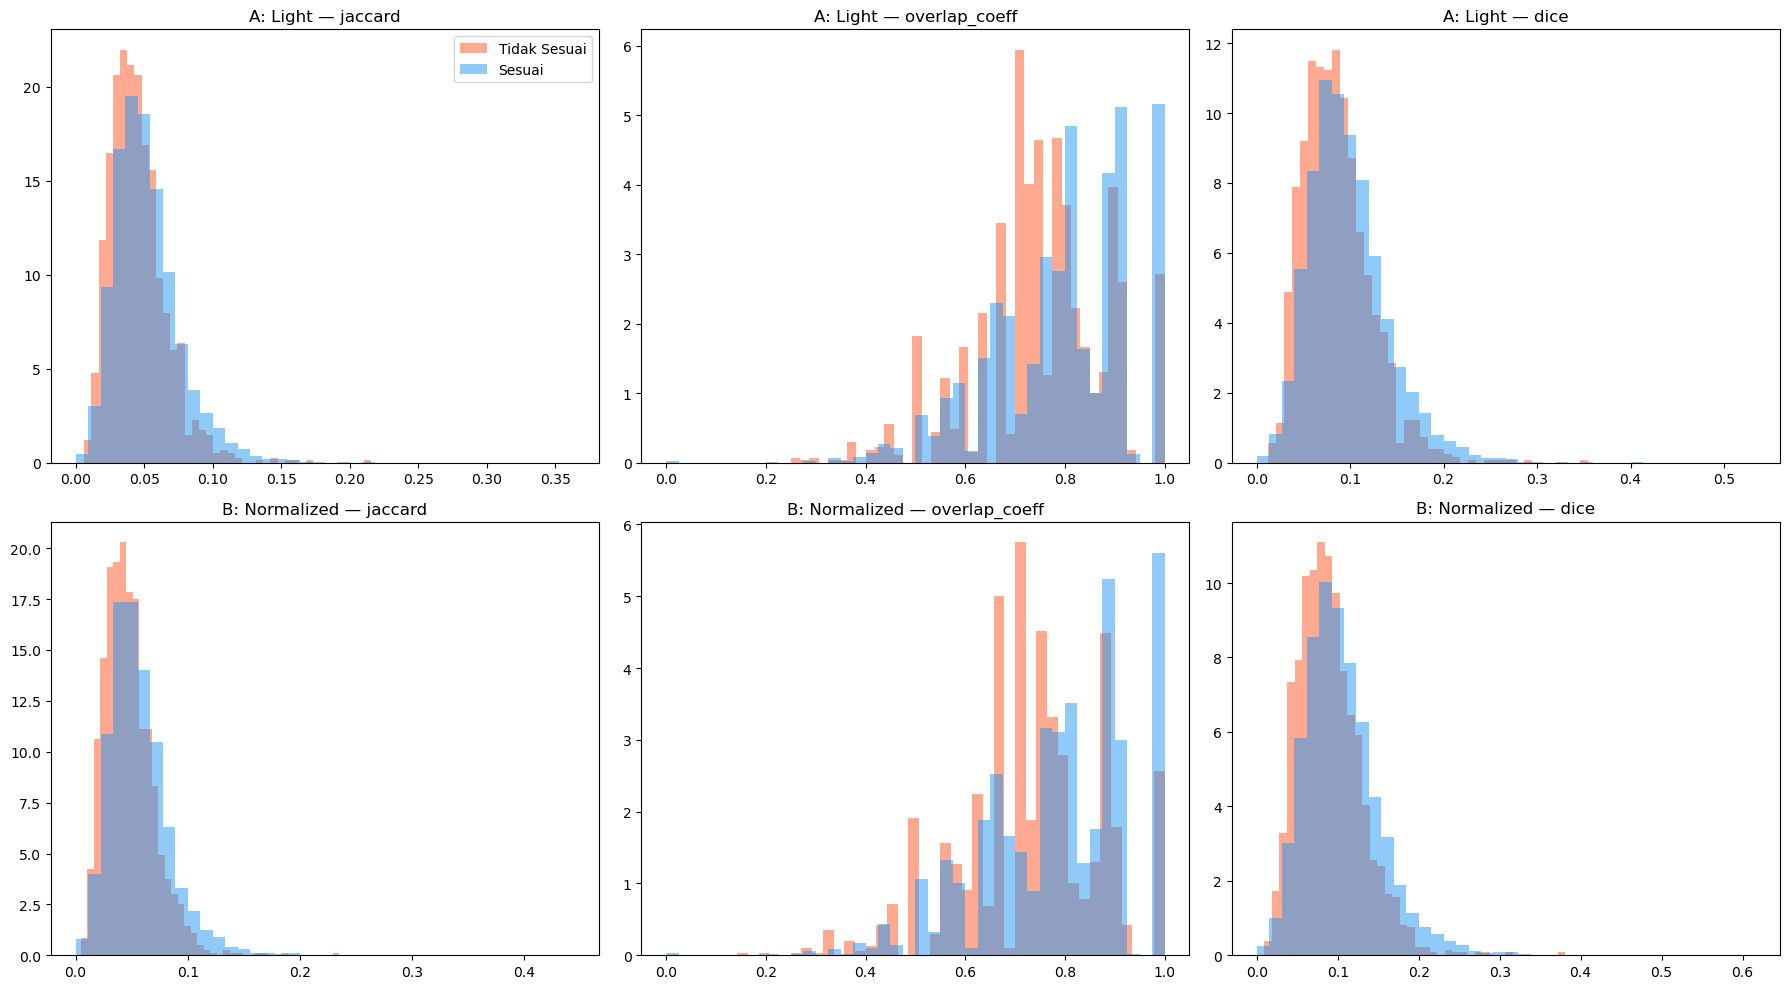

In [13]:
def lexical_overlap(headline, article):
    h_tokens = set(str(headline).lower().split())
    a_tokens = set(str(article).lower().split())
    intersection = h_tokens & a_tokens
    union = h_tokens | a_tokens
    jaccard = len(intersection) / len(union) if len(union) > 0 else 0
    overlap_coeff = len(intersection) / min(len(h_tokens), len(a_tokens)) if min(len(h_tokens), len(a_tokens)) > 0 else 0
    dice = 2 * len(intersection) / (len(h_tokens) + len(a_tokens)) if (len(h_tokens) + len(a_tokens)) > 0 else 0
    return jaccard, overlap_coeff, dice

variants = [
    ('clean_a', f'{headline_col}_clean_a', f'{article_col}_clean_a', 'A: Light'),
    ('clean_b', f'{headline_col}_clean_b', f'{article_col}_clean_b', 'B: Normalized'),
]

metrics_list = ['jaccard', 'overlap_coeff', 'dice']
colors = {1: '#2196F3', 0: '#FF5722'}
overlap_sep_rows = []

for suffix, h_col, a_col, display_name in variants:
    print(f"\n=== Lexical Overlap: {display_name} ===")
    overlap_data = train.apply(lambda row: lexical_overlap(row[h_col], row[a_col]), axis=1)
    overlap_df = pd.DataFrame(overlap_data.tolist(), columns=metrics_list, index=train.index)
    for m in metrics_list:
        train[f'{m}_{suffix}'] = overlap_df[m]

    for metric in metrics_list:
        print(f"\n  {metric}:")
        for lbl in sorted(train[label_col].unique()):
            s = train[train[label_col] == lbl][f'{metric}_{suffix}']
            lbl_name = label_names.get(int(lbl), str(lbl))
            print(f"    {lbl_name}: mean={s.mean():.4f}, median={s.median():.4f}")

    for metric in metrics_list:
        col_name = f'{metric}_{suffix}'
        mean_1 = train[train[label_col] == 1][col_name].mean()
        mean_0 = train[train[label_col] == 0][col_name].mean()
        gap = abs(mean_1 - mean_0)
        overlap_sep_rows.append({
            'variant': display_name, 'metric': metric,
            'mean_Sesuai': round(mean_1, 4), 'mean_TidakSesuai': round(mean_0, 4),
            'separation_gap': round(gap, 4), 'source': 'lexical_overlap'
        })

# Visualization
fig, axes = plt.subplots(len(variants), 3, figsize=(18, 5 * len(variants)))
for row_idx, (suffix, h_col, a_col, display_name) in enumerate(variants):
    for col_idx, metric in enumerate(metrics_list):
        ax = axes[row_idx, col_idx]
        col_name = f'{metric}_{suffix}'
        for lbl in sorted(train[label_col].unique()):
            subset = train[train[label_col] == lbl][col_name]
            lbl_name = label_names.get(int(lbl), str(lbl))
            ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
        ax.set_title(f'{display_name} — {metric}')
        if row_idx == 0 and col_idx == 0:
            ax.legend()
plt.tight_layout()
plt.show()


=== LSA Cosine Similarity (clean_b only) ===
  TF-IDF shape: (28794, 10000), LSA explained variance: 0.2200
  Saved tfidf_lsa_vectorizer.joblib + svd_lsa_model.joblib
    Tidak Sesuai: mean=0.5204, median=0.5314
    Sesuai: mean=0.5609, median=0.5778
  Separability gap: 0.0405


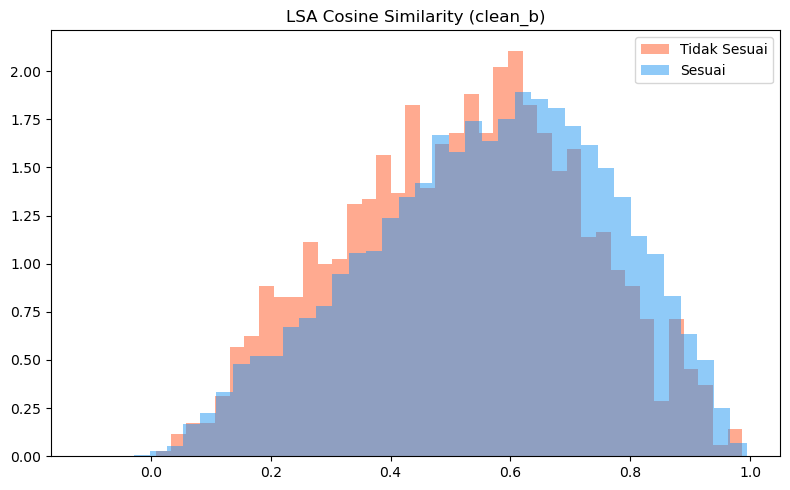

[MEMORY after cleanup] 722.8 MB
  Time: 25.5s


In [14]:
print("=== LSA Cosine Similarity (clean_b only) ===")
t0 = time.time()

h_col = f'{headline_col}_clean_b'
a_col = f'{article_col}_clean_b'

all_text = pd.concat([train[h_col], train[a_col]]).astype(str)
tfidf_lsa = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
tfidf_matrix = tfidf_lsa.fit_transform(all_text)

n_components = 100
svd_lsa = TruncatedSVD(n_components=n_components, random_state=SEED)
lsa_matrix = svd_lsa.fit_transform(tfidf_matrix)
explained_var = svd_lsa.explained_variance_ratio_.sum()
print(f"  TF-IDF shape: {tfidf_matrix.shape}, LSA explained variance: {explained_var:.4f}")

n_train = len(train)
lsa_headline = lsa_matrix[:n_train]
lsa_article = lsa_matrix[n_train:2*n_train]

lsa_sim = np.array([
    cosine_similarity(lsa_headline[i:i+1], lsa_article[i:i+1])[0,0]
    for i in range(n_train)
])

train['feat_lsa_cosine_sim'] = lsa_sim

models_dir = '../data/processing'
os.makedirs(models_dir, exist_ok=True)
import joblib
joblib.dump(tfidf_lsa, os.path.join(models_dir, 'tfidf_lsa_vectorizer.joblib'))
joblib.dump(svd_lsa, os.path.join(models_dir, 'svd_lsa_model.joblib'))
print(f"  Saved tfidf_lsa_vectorizer.joblib + svd_lsa_model.joblib")

for lbl in sorted(train[label_col].unique()):
    s = train[train[label_col] == lbl]['feat_lsa_cosine_sim']
    lbl_name = label_names.get(int(lbl), str(lbl))
    print(f"    {lbl_name}: mean={s.mean():.4f}, median={s.median():.4f}")

mean_1 = train[train[label_col] == 1]['feat_lsa_cosine_sim'].mean()
mean_0 = train[train[label_col] == 0]['feat_lsa_cosine_sim'].mean()
print(f"  Separability gap: {abs(mean_1-mean_0):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
for lbl in sorted(train[label_col].unique()):
    subset = train[train[label_col] == lbl]['feat_lsa_cosine_sim']
    lbl_name = label_names.get(int(lbl), str(lbl))
    ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
ax.set_title('LSA Cosine Similarity (clean_b)')
ax.legend()
plt.tight_layout()
plt.show()

# Cleanup large matrices
del tfidf_matrix, lsa_matrix, lsa_headline, lsa_article
cleanup()

print(f"  Time: {time.time()-t0:.1f}s")


In [15]:
all_sep = pd.DataFrame(overlap_sep_rows)
all_sep = all_sep.sort_values('separation_gap', ascending=False).reset_index(drop=True)

print("=" * 80)
print("  COMPARATIVE SEPARABILITY SUMMARY")
print("=" * 80)
print(all_sep.to_string(index=False))

print("\n=== TOP 5 Most Discriminative Features ===")
for i, row in all_sep.head(5).iterrows():
    print(f"  {row['source']:20s} | {row['variant']:15s} | {row['metric']:20s} | gap={row['separation_gap']:.4f}")

print("\n=== BEST VARIANT per SOURCE ===")
for src in all_sep['source'].unique():
    subset = all_sep[all_sep['source'] == src]
    best = subset.iloc[0]
    print(f"  {src:20s} -> {best['variant']:15s} | gap={best['separation_gap']:.4f}")


  COMPARATIVE SEPARABILITY SUMMARY
      variant        metric  mean_Sesuai  mean_TidakSesuai  separation_gap          source
B: Normalized overlap_coeff       0.7851            0.7295          0.0556 lexical_overlap
     A: Light overlap_coeff       0.7957            0.7494          0.0463 lexical_overlap
B: Normalized          dice       0.1049            0.0900          0.0149 lexical_overlap
     A: Light          dice       0.0978            0.0859          0.0118 lexical_overlap
B: Normalized       jaccard       0.0560            0.0476          0.0084 lexical_overlap
     A: Light       jaccard       0.0519            0.0453          0.0066 lexical_overlap

=== TOP 5 Most Discriminative Features ===
  lexical_overlap      | B: Normalized   | overlap_coeff        | gap=0.0556
  lexical_overlap      | A: Light        | overlap_coeff        | gap=0.0463
  lexical_overlap      | B: Normalized   | dice                 | gap=0.0149
  lexical_overlap      | A: Light        | dice      

In [16]:
pipeline_config = {
    "pipeline_version": "v1",
    "created_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
    "dataset": {
        "train_rows": int(len(train)),
        "test_rows": int(len(test)),
        "columns": {"headline": headline_col, "article": article_col, "label": label_col}
    },
    "preprocessing": {
        "variants": {
            "A_light": ["normalize_whitespace", "remove_url", "remove_html", "remove_noise"],
            "B_normalized": ["normalize_whitespace", "remove_url", "remove_html", "remove_noise", "lowercase", "stopword_removal"]
        },
        "stopword_source": "Sastrawi",
        "tokenization": "spacy.blank('id') — tokenizer only, no POS/dependency parser native for id",
        "limitations": [
            "spaCy blank('id') tidak punya POS tagger atau dependency parser native untuk Bahasa Indonesia",
            "Fitur linguistik/relasi pakai heuristik regex + wordlist, bukan true NLP parsing"
        ]
    },
    "features": {
        "lsa_cosine_sim": {"n_components": 100, "source": "clean_b"},
        "lexical_overlap": {"metrics": ["jaccard", "overlap_coeff", "dice"], "variants": ["clean_a", "clean_b"]}
    },
    "eda_comparison": all_sep.to_dict(orient='records')
}

with open(os.path.join(models_dir, 'pipeline_config_v1.json'), 'w', encoding='utf-8') as f:
    json.dump(pipeline_config, f, indent=2, ensure_ascii=False)
print("Pipeline config v1 saved")


Pipeline config v1 saved


In [33]:
class LexicalFeatures(BaseEstimator, TransformerMixin):
    """Jaccard, overlap coefficient, dice from BOTH clean_a (entity-aware) and clean_b (content-only)."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # clean_b (tokens-based)
        results_b = X.apply(lambda row: self._compute_tokens(
            row[f'{headline_col}_tokens'], row[f'{article_col}_tokens']
        ), axis=1)
        df_b = pd.DataFrame(results_b.tolist(), columns=[
            'feat_jaccard_b', 'feat_overlap_coeff_b', 'feat_dice_b'
        ], index=X.index)

        # clean_a (raw text-based — preserves capitalization for entity overlap)
        results_a = X.apply(lambda row: self._compute_text(
            row[f'{headline_col}_clean_a'], row[f'{article_col}_clean_a']
        ), axis=1)
        df_a = pd.DataFrame(results_a.tolist(), columns=[
            'feat_jaccard_a', 'feat_overlap_coeff_a'
        ], index=X.index)

        return pd.concat([df_a, df_b], axis=1)

    @staticmethod
    def _compute_tokens(headline_tokens, article_tokens):
        h = set(headline_tokens) if isinstance(headline_tokens, list) else set(str(headline_tokens).split())
        a = set(article_tokens) if isinstance(article_tokens, list) else set(str(article_tokens).split())
        intersection = h & a
        union = h | a
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0
        overlap_coeff = len(intersection) / min(len(h), len(a)) if min(len(h), len(a)) > 0 else 0
        dice = 2 * len(intersection) / (len(h) + len(a)) if (len(h) + len(a)) > 0 else 0
        return jaccard, overlap_coeff, dice

    @staticmethod
    def _compute_text(headline_text, article_text):
        h = set(str(headline_text).lower().split())
        a = set(str(article_text).lower().split())
        intersection = h & a
        union = h | a
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0
        overlap_coeff = len(intersection) / min(len(h), len(a)) if min(len(h), len(a)) > 0 else 0
        return jaccard, overlap_coeff

print("LexicalFeatures class defined (5 features: jaccard_a, overlap_a, jaccard_b, overlap_b, dice_b)")


LexicalFeatures class defined (5 features: jaccard_a, overlap_a, jaccard_b, overlap_b, dice_b)


In [96]:

class EntityNumericFeatures(BaseEstimator, TransformerMixin):
    """Proxy NER, numeric mismatch, date mismatch from raw text."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        results = X.apply(
            lambda row: self._compute(row),
            axis=1
        )

        df = pd.DataFrame(
            results.tolist(),
            columns=[
                'feat_proxy_ner_intersection',
                'feat_numeric_mismatch_count',
                'feat_numeric_total',
                'feat_date_mismatch',
                'feat_entity_ratio'
            ],
            index=X.index
        )

        return df

    def _compute(self, row):
        h_raw = str(row[f'{headline_col}_clean_a'])
        a_raw = str(row[f'{article_col}_clean_a'])

        # =========================================================
        # Proxy NER: capitalized words, excluding sentence-start
        # =========================================================
        h_caps = self._extract_capitalized_entities(h_raw)
        a_caps = self._extract_capitalized_entities(a_raw)

        ner_inter = len(h_caps & a_caps)

        ner_ratio = (
            ner_inter / len(h_caps)
            if len(h_caps) > 0
            else 0
        )

        # =========================================================
        # Numeric mismatch
        # =========================================================
        h_nums = re.findall(
            r'\d+(?:[.,]\d+)?',
            h_raw
        )

        a_nums = re.findall(
            r'\d+(?:[.,]\d+)?',
            a_raw
        )

        a_nums_set = set(a_nums)

        mismatch = sum(
            1 for n in h_nums
            if n not in a_nums_set
        )

        num_total = len(h_nums) + len(a_nums)

        # =========================================================
        # Date mismatch
        # =========================================================
        h_dates = self._extract_dates(h_raw)
        a_dates = self._extract_dates(a_raw)

        date_mismatch = (
            1
            if (
                h_dates
                and a_dates
                and set(h_dates) != set(a_dates)
            )
            else 0
        )

        return (
            ner_inter,
            mismatch,
            num_total,
            date_mismatch,
            ner_ratio
        )

    @staticmethod
    def _extract_capitalized_entities(text):
        """
        Extract capitalized words while excluding the first word
        of each sentence.

        Example:
            "President Joko visited Jakarta. He met Alice."

        Returns approximately:
            {"Joko", "Jakarta", "Alice"}

        This is only a heuristic proxy for NER.
        """

        entities = set()

        # Split text into sentences.
        sentences = re.split(r'[.!?]+\s*', str(text))

        for sentence in sentences:
            words = re.findall(
                r'\b[A-Z][a-z]+\b',
                sentence
            )

            # Ignore the first capitalized word because it may simply
            # be capitalized due to being at the beginning of a sentence.
            if words:
                entities.update(words[1:])

        return entities

    @staticmethod
    def _extract_dates(text):
        months = WORDLISTS['month_names']

        dates = []

        # Numeric dates:
        # 12/05/2026
        # 12-05-2026
        # 12.05.2026
        dates.extend(
            re.findall(
                r'\b\d{1,2}[./-]\d{1,2}[./-]\d{2,4}\b',
                text
            )
        )

        # Written dates:
        # 12 January 2026
        # 12 januari 2026
        for month in months:
            dates.extend(
                re.findall(
                    rf'\b\d{{1,2}}\s+{re.escape(month)}\s+\d{{2,4}}\b',
                    text,
                    re.IGNORECASE
                )
            )

        return dates


print("EntityNumericFeatures class defined")



EntityNumericFeatures class defined


In [35]:
class PositionFeatures(BaseEstimator, TransformerMixin):
    """Lead paragraph match and headline coverage ratio."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        results = X.apply(lambda row: self._compute(row), axis=1)
        df = pd.DataFrame(results.tolist(), columns=[
            'feat_lead_paragraph_match', 'feat_headline_coverage_ratio'
        ], index=X.index)
        return df

    def _compute(self, row):
        h_tokens = set(row[f'{headline_col}_tokens']) if isinstance(row[f'{headline_col}_tokens'], list) else set(str(row[f'{headline_col}_tokens']).split())
        a_tokens_list = row[f'{article_col}_tokens'] if isinstance(row[f'{article_col}_tokens'], list) else str(row[f'{article_col}_tokens']).split()
        a_text = str(row[f'{article_col}_clean_b'])

        # Split article into sentences (simple regex)
        sentences = re.split(r'[.!?]+', a_text)
        sentences = [s.strip() for s in sentences if s.strip()]

        # First 3 sentences
        early_sents = ' '.join(sentences[:3])
        early_tokens = set(early_sents.split())

        # Headline keywords in early vs total
        early_count = len(h_tokens & early_tokens)
        total_count = len(h_tokens & set(a_tokens_list))
        lead_match = early_count / total_count if total_count > 0 else 0

        # Coverage ratio
        coverage = total_count / len(h_tokens) if len(h_tokens) > 0 else 0

        return lead_match, coverage

print("PositionFeatures class defined")


PositionFeatures class defined


In [36]:
class LinguisticFeatures(BaseEstimator, TransformerMixin):
    """Sentiment gap, superlative ratio, discourse markers, negation scope, readability gap."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        results = X.apply(lambda row: self._compute(row), axis=1)
        df = pd.DataFrame(results.tolist(), columns=[
            'feat_sentiment_gap', 'feat_superlative_ratio',
            'feat_discourse_marker_count', 'feat_negation_contradiction',
            'feat_readability_gap'
        ], index=X.index)
        return df

    def _compute(self, row):
        h_clean = str(row[f'{headline_col}_clean_b'])
        a_clean = str(row[f'{article_col}_clean_b'])
        h_raw = str(row[f'{headline_col}_clean_a'])
        a_raw = str(row[f'{article_col}_clean_a'])

        # Sentiment gap
        h_sent = self._sentiment_score(h_clean)
        a_sent = self._sentiment_score(a_clean)
        sent_gap = abs(h_sent - a_sent)

        # Superlative ratio
        h_words = h_raw.lower().split()
        super_count = sum(1 for w in h_words if w in WORDLISTS['superlatives'])
        super_ratio = super_count / len(h_words) if len(h_words) > 0 else 0

        # Discourse markers in article near headline overlap
        a_sentences = re.split(r'[.!?]+', a_raw)
        a_sentences = [s.strip().lower() for s in a_sentences if s.strip()]
        h_words_set = set(h_clean.split())

        discourse_count = 0
        for i, sent in enumerate(a_sentences):
            sent_words = set(sent.split())
            if h_words_set & sent_words:  # overlap exists
                # Check window ±1
                for j in [i-1, i, i+1]:
                    if 0 <= j < len(a_sentences):
                        for marker in WORDLISTS['discourse_markers']:
                            if marker in a_sentences[j]:
                                discourse_count += 1
        discourse_count = min(discourse_count, 1)  # binary: ada atau tidak

        # Negation contradiction
        a_words = a_clean.split()
        negation_found = False
        for i, w in enumerate(a_words):
            if w in WORDLISTS['negation_words']:
                # Get object (3 tokens after negation)
                obj_tokens = a_words[i+1:i+4]
                if obj_tokens:
                    obj = set(obj_tokens)
                    # Check if obj appears in headline WITHOUT negation
                    if obj & h_words_set:
                        negation_found = True
                        break
        negation_contra = 1 if negation_found else 0

        # Readability gap
        h_sents = re.split(r'[.!?]+', h_raw)
        h_sents = [s.strip() for s in h_sents if s.strip()]
        a_sents = re.split(r'[.!?]+', a_raw)
        a_sents = [s.strip() for s in a_sents if s.strip()]

        h_avg_sent_len = np.mean([len(s.split()) for s in h_sents]) if h_sents else 0
        a_avg_sent_len = np.mean([len(s.split()) for s in a_sents]) if a_sents else 0
        h_avg_word_len = np.mean([len(w) for w in h_raw.split()]) if h_raw.split() else 0
        a_avg_word_len = np.mean([len(w) for w in a_raw.split()]) if a_raw.split() else 0

        read_gap = abs(h_avg_sent_len - a_avg_sent_len) + abs(h_avg_word_len - a_avg_word_len)

        return sent_gap, super_ratio, discourse_count, negation_contra, read_gap

    @staticmethod
    def _sentiment_score(text):
        words = text.lower().split()
        scores = [SENTIMENT_LEXICON[w] for w in words if w in SENTIMENT_LEXICON]
        return np.mean(scores) if scores else 0

print("LinguisticFeatures class defined")


LinguisticFeatures class defined


In [37]:
class RelationFeatures(BaseEstimator, TransformerMixin):
    """Event extraction (action verbs) and heuristic SVO overlap."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        results = X.apply(lambda row: self._compute(row), axis=1)
        df = pd.DataFrame(results.tolist(), columns=[
            'feat_event_extraction', 'feat_svo_overlap', 'feat_relation_score'
        ], index=X.index)
        return df

    def _compute(self, row):
        h_tokens = row[f'{headline_col}_tokens'] if isinstance(row[f'{headline_col}_tokens'], list) else str(row[f'{headline_col}_tokens']).split()
        a_tokens = row[f'{article_col}_tokens'] if isinstance(row[f'{article_col}_tokens'], list) else str(row[f'{article_col}_tokens']).split()
        action_verbs = set(WORDLISTS['action_verbs'])

        # Event extraction: action verbs in headline that co-occur in article
        h_verbs = [v for v in h_tokens if v in action_verbs]
        a_text = ' '.join(a_tokens)
        event_matches = sum(1 for v in h_verbs if v in a_text)
        event_ratio = event_matches / len(h_verbs) if h_verbs else 0

        # Heuristic SVO extraction
        svo_h = self._heuristic_svo(h_tokens, action_verbs)
        svo_a = self._heuristic_svo(a_tokens, action_verbs)

        svo_overlap = 0
        if svo_h and svo_a:
            h_svo_set = set(tuple(svo) for svo in svo_h)
            a_svo_set = set(tuple(svo) for svo in svo_a)
            intersection = h_svo_set & a_svo_set
            svo_overlap = len(intersection) / len(h_svo_set) if h_svo_set else 0

        # Combined relation score
        relation_score = (event_ratio + svo_overlap) / 2

        return event_ratio, svo_overlap, relation_score

    @staticmethod
    def _heuristic_svo(tokens, action_verbs):
        """Extract subject-verb-object triples using wordlist-based heuristic."""
        svo_triples = []
        for i, token in enumerate(tokens):
            if token in action_verbs:
                subject = tokens[max(0, i-2):i]
                obj = tokens[i+1:min(len(tokens), i+3)]
                if subject and obj:
                    svo_triples.append((subject[-1] if subject else '', token, obj[0] if obj else ''))
        return svo_triples

print("RelationFeatures class defined")


RelationFeatures class defined


In [38]:
class StylisticFeatures(BaseEstimator, TransformerMixin):
    """Exclamation count, caps ratio, buzzword count from clean_a (preserves punctuation)."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        results = X.apply(lambda row: self._compute(row), axis=1)
        df = pd.DataFrame(results.tolist(), columns=[
            'feat_exclamation_count', 'feat_caps_ratio', 'feat_buzzword_count'
        ], index=X.index)
        return df

    def _compute(self, row):
        h_raw = str(row[f'{headline_col}_clean_a'])

        # Exclamation count
        excl_count = h_raw.count('!')

        # Caps ratio (words >= 3 chars, all uppercase)
        words = h_raw.split()
        caps_words = [w for w in words if len(w) >= 3 and w.isupper()]
        caps_ratio = len(caps_words) / len(words) if words else 0

        # Buzzword count
        h_lower = h_raw.lower()
        buzz_count = sum(1 for b in WORDLISTS['buzzwords'] if b in h_lower)

        return excl_count, caps_ratio, buzz_count

print("StylisticFeatures class defined")


StylisticFeatures class defined


In [44]:
class TfIdfCosineFeatures(BaseEstimator, TransformerMixin):
    """
    TF-IDF word 1-2 gram cosine similarity between headline and article.

    Stateful:
    - Vectorizer is fitted on training data only.
    - The fitted vectorizer is reused for test/inference.
    """

    def __init__(self, max_features=10000, ngram_range=(1, 2)):
        self.max_features = max_features
        self.ngram_range = ngram_range

    def fit(self, X, y=None):
        self.vectorizer_ = TfidfVectorizer(
            max_features=self.max_features,
            ngram_range=self.ngram_range
        )

        # Fit vocabulary using both headline and article text
        all_text = pd.concat([
            X[f'{headline_col}_clean_b'].astype(str),
            X[f'{article_col}_clean_b'].astype(str)
        ])

        self.vectorizer_.fit(all_text)

        return self

    def transform(self, X):
        if not hasattr(self, 'vectorizer_'):
            raise RuntimeError(
                "TfIdfCosineFeatures has not been fitted yet."
            )

        h_text = X[f'{headline_col}_clean_b'].astype(str)
        a_text = X[f'{article_col}_clean_b'].astype(str)

        # Transform using the SAME fitted vectorizer
        tfidf_h = self.vectorizer_.transform(h_text)
        tfidf_a = self.vectorizer_.transform(a_text)

        # TF-IDF vectors are L2-normalized by default,
        # so dot product = cosine similarity
        cosine_sim = np.asarray(
            tfidf_h.multiply(tfidf_a).sum(axis=1)
        ).ravel()

        return pd.DataFrame(
            {
                'feat_tfidf_cosine': cosine_sim
            },
            index=X.index
        )


print("TfIdfCosineFeatures class defined")

TfIdfCosineFeatures class defined


In [42]:

class LengthRatioFeatures(BaseEstimator, TransformerMixin):
    """
    Word length ratio and character length ratio
    between headline and article.

    Stateless transformer.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        # =========================================================
        # Word length
        # =========================================================
        # Use token lists generated by TextPreprocessor
        h_word_len = X[f'{headline_col}_tokens'].apply(len)
        a_word_len = X[f'{article_col}_tokens'].apply(len)

        # Avoid division by zero
        a_word_len_safe = a_word_len.replace(0, np.nan)

        word_ratio = (
            h_word_len / a_word_len_safe
        ).fillna(0)

        # =========================================================
        # Character length
        # =========================================================
        # Use clean_a text before lowercase/stopword removal
        h_char_len = X[f'{headline_col}_clean_a'].str.len()
        a_char_len = X[f'{article_col}_clean_a'].str.len()

        # Avoid division by zero
        a_char_len_safe = a_char_len.replace(0, np.nan)

        char_ratio = (
            h_char_len / a_char_len_safe
        ).fillna(0)

        # =========================================================
        # Return features
        # =========================================================
        return pd.DataFrame({
            'feat_word_length_ratio': word_ratio,
            'feat_char_length_ratio': char_ratio
        }, index=X.index)


print("LengthRatioFeatures class defined")



LengthRatioFeatures class defined


In [90]:
class KeywordAlignmentFeatures(BaseEstimator, TransformerMixin):
    """Extract headline keywords via TF-IDF, check alignment with article context."""

    def __init__(self, top_k=3):
        self.top_k = top_k
        self.vectorizer_ = None

    def fit(self, X, y=None):
        self.vectorizer_ = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
        all_text = pd.concat([
            X[f'{headline_col}_clean_b'].astype(str),
            X[f'{article_col}_clean_b'].astype(str)
        ])
        self.vectorizer_.fit(all_text)
        return self

    def transform(self, X):
        results = X.apply(lambda row: self._compute(row), axis=1)
        df = pd.DataFrame(results.tolist(), columns=[
            'feat_keyword_coverage', 'feat_keyword_context_match',
            'feat_keyword_absent_count'
        ], index=X.index)
        return df

    def _compute(self, row):
        h_text = str(row[f'{headline_col}_clean_b'])
        a_text = str(row[f'{article_col}_clean_b'])

        if not h_text.strip() or not a_text.strip():
            return 0, 0, 0

        # Get top TF-IDF keywords from headline
        h_tfidf = self.vectorizer_.transform([h_text])
        feature_names = self.vectorizer_.get_feature_names_out()
        top_indices = h_tfidf.toarray().flatten().argsort()[-self.top_k:][::-1]
        keywords = [feature_names[i] for i in top_indices if h_tfidf[0, i] > 0]

        if not keywords:
            return 0, 0, 0

        a_words = set(a_text.split())

        # Keyword coverage: how many headline keywords appear in article
        found = sum(1 for kw in keywords if kw in a_words)
        coverage = found / len(keywords)

        # Context match: keyword appears ±2 words from same keyword in article
        a_tokens = a_text.split()
        context_matches = 0
        for kw in keywords:
            if kw in a_tokens:
                idx = a_tokens.index(kw)
                context_matches += 1
        context_match = context_matches / len(keywords)

        # Absent keywords count
        absent = len(keywords) - found

        return coverage, context_match, absent

print("KeywordAlignmentFeatures class defined")


KeywordAlignmentFeatures class defined


In [91]:
class EntityOverlapFeatures(BaseEstimator, TransformerMixin):
    """Named entity overlap using regex patterns for ID names, organizations, locations."""

    # Patterns for Indonesian entity types
    PERSON_PATTERNS = [
        r'\b(?:Mr|Mrs|Ir|Dr|Prof|Hj|H\.?|Bapak|Ibu|Sdr|Sdri)\.?\s+[A-Z][a-z]+',
        r'\b[A-Z][a-z]+\s+[A-Z][a-z]+\b',  # Two consecutive capitalized words
    ]
    ORG_PATTERNS = [
        r'\b(?:PT|CV|Bank|Ministry|Kementerian|Dinas|Polri|TNI|DPR|MPR|KPK)\b',
        r'\b[A-Z][a-z]+(?:Group|Corp|Inc|Ltd|Bank|University|Institute)\b',
    ]
    LOCATION_PATTERNS = [
        r'\b(?:Jakarta|Surabaya|Bandung|Medan|Semarang|Makassar|Palembang|'
        r'Denpasar|Yogyakarta|Malang|Bogor|Depok|Tangerang|Bekasi|'
        r'Indonesia|Jawa|Sumatera|Kalimantan|Sulawesi|Bali|Papua)\b',
    ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        results = X.apply(lambda row: self._compute(row), axis=1)
        df = pd.DataFrame(results.tolist(), columns=[
            'feat_person_overlap', 'feat_org_overlap',
            'feat_location_overlap', 'feat_entity_overlap_ratio'
        ], index=X.index)
        return df

    def _compute(self, row):
        h_raw = str(row[f'{headline_col}_clean_a'])
        a_raw = str(row[f'{article_col}_clean_a'])

        h_persons = self._extract_entities(h_raw, self.PERSON_PATTERNS)
        a_persons = self._extract_entities(a_raw, self.PERSON_PATTERNS)
        person_overlap = len(h_persons & a_persons) / max(len(h_persons), 1)

        h_orgs = self._extract_entities(h_raw, self.ORG_PATTERNS)
        a_orgs = self._extract_entities(a_raw, self.ORG_PATTERNS)
        org_overlap = len(h_orgs & a_orgs) / max(len(h_orgs), 1)

        h_locs = self._extract_entities(h_raw, self.LOCATION_PATTERNS)
        a_locs = self._extract_entities(a_raw, self.LOCATION_PATTERNS)
        loc_overlap = len(h_locs & a_locs) / max(len(h_locs), 1)

        # Overall entity overlap
        h_all = h_persons | h_orgs | h_locs
        a_all = a_persons | a_orgs | a_locs
        entity_ratio = len(h_all & a_all) / max(len(h_all), 1)

        return person_overlap, org_overlap, loc_overlap, entity_ratio

    @staticmethod
    def _extract_entities(text, patterns):
        entities = set()
        for pattern in patterns:
            matches = re.findall(pattern, text)
            entities.update(matches)
        return entities

print("EntityOverlapFeatures class defined")


EntityOverlapFeatures class defined


In [92]:
class TopicCoherenceFeatures(BaseEstimator, TransformerMixin):
    """NMF topic coherence between headline and article."""

    def __init__(self, n_topics=5):
        self.n_topics = n_topics
        self.vectorizer_ = None
        self.nmf_model_ = None

    def fit(self, X, y=None):
        from sklearn.decomposition import NMF

        self.vectorizer_ = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
        all_text = pd.concat([
            X[f'{headline_col}_clean_b'].astype(str),
            X[f'{article_col}_clean_b'].astype(str)
        ])
        tfidf_matrix = self.vectorizer_.fit_transform(all_text)

        self.nmf_model_ = NMF(
            n_components=self.n_topics, random_state=SEED,
            max_iter=200, init='nndsvd'
        )
        self.nmf_model_.fit(tfidf_matrix)
        return self

    def transform(self, X):
        h_text = X[f'{headline_col}_clean_b'].astype(str)
        a_text = X[f'{article_col}_clean_b'].astype(str)

        all_text = pd.concat([h_text, a_text])
        tfidf_matrix = self.vectorizer_.transform(all_text)
        topic_dists = self.nmf_model_.transform(tfidf_matrix)

        n = len(X)
        h_topics = topic_dists[:n]
        a_topics = topic_dists[n:2*n]

        # Cosine similarity between topic distributions
        topic_cosine = np.array([
            cosine_similarity(h_topics[i:i+1], a_topics[i:i+1])[0, 0]
            for i in range(n)
        ])

        # Dominant topic match
        h_dominant = h_topics.argmax(axis=1)
        a_dominant = a_topics.argmax(axis=1)
        topic_match = (h_dominant == a_dominant).astype(float)

        # Topic KL divergence (lower = more similar)
        h_norm = h_topics / (h_topics.sum(axis=1, keepdims=True) + 1e-10)
        a_norm = a_topics / (a_topics.sum(axis=1, keepdims=True) + 1e-10)
        kl_div = np.sum(h_norm * np.log((h_norm + 1e-10) / (a_norm + 1e-10)), axis=1)
        kl_div_normalized = kl_div / np.log(self.n_topics)

        return pd.DataFrame({
            'feat_topic_cosine': topic_cosine,
            'feat_topic_match': topic_match,
            'feat_topic_kl_div': kl_div_normalized
        }, index=X.index)

print("TopicCoherenceFeatures class defined")


TopicCoherenceFeatures class defined


In [98]:
print("=== Building Feature Pipeline ===")
t0 = time.time()

feature_pipeline = FeatureUnion([
    ('lexical', LexicalFeatures()),
    ('entity_numeric', EntityNumericFeatures()),
    ('position', PositionFeatures()),
    ('linguistic', LinguisticFeatures()),
    ('relation', RelationFeatures()),
    ('stylistic', StylisticFeatures()),
    ('tfidf_cosine', TfIdfCosineFeatures()),
    ('length_ratio', LengthRatioFeatures()),
    ('keyword_alignment', KeywordAlignmentFeatures()),
    ('entity_overlap', EntityOverlapFeatures()),
    ('topic_coherence', TopicCoherenceFeatures()),
])

# Fit and transform to get feature matrix
X_features = feature_pipeline.fit_transform(train)

# Extract proper feature names from each transformer
feature_names = []
for name, transformer in feature_pipeline.transformer_list:
    sample_out = transformer.transform(train.head(1))
    if hasattr(sample_out, 'shape'):
        n_feats = sample_out.shape[1]
    else:
        n_feats = len(sample_out.columns) if hasattr(sample_out, 'columns') else len(sample_out)
    for i in range(n_feats):
        feature_names.append(f'{name}_{i}')

print(f"  Feature matrix shape: {X_features.shape}")
print(f"  Feature names ({len(feature_names)}): {feature_names}")

# Create DataFrame with proper names
X_df = pd.DataFrame(X_features, columns=feature_names, index=train.index)

# Add LSA cosine sim
X_df['feat_lsa_cosine_sim'] = train['feat_lsa_cosine_sim'].values

# Save fitted TF-IDF vectorizer for test-time inference
tfidf_cosine_transformer = dict(
    feature_pipeline.transformer_list
)['tfidf_cosine']
if hasattr(tfidf_cosine_transformer, 'vectorizer_') and tfidf_cosine_transformer.vectorizer_ is not None:
    joblib.dump(tfidf_cosine_transformer.vectorizer_, os.path.join(models_dir, 'tfidf_cosine_vectorizer.joblib'))
    print(f"  Saved tfidf_cosine_vectorizer.joblib")

print(f"  Final feature count: {X_df.shape[1]}")
print(f"  Time: {time.time()-t0:.1f}s")


=== Building Feature Pipeline ===
  Feature matrix shape: (14397, 36)
  Feature names (36): ['lexical_0', 'lexical_1', 'lexical_2', 'lexical_3', 'lexical_4', 'entity_numeric_0', 'entity_numeric_1', 'entity_numeric_2', 'entity_numeric_3', 'entity_numeric_4', 'position_0', 'position_1', 'linguistic_0', 'linguistic_1', 'linguistic_2', 'linguistic_3', 'linguistic_4', 'relation_0', 'relation_1', 'relation_2', 'stylistic_0', 'stylistic_1', 'stylistic_2', 'tfidf_cosine_0', 'length_ratio_0', 'length_ratio_1', 'keyword_alignment_0', 'keyword_alignment_1', 'keyword_alignment_2', 'entity_overlap_0', 'entity_overlap_1', 'entity_overlap_2', 'entity_overlap_3', 'topic_coherence_0', 'topic_coherence_1', 'topic_coherence_2']
  Saved tfidf_cosine_vectorizer.joblib
  Final feature count: 37
  Time: 99.9s


In [99]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, matthews_corrcoef, balanced_accuracy_score, f1_score

print("=== Dummy Baseline ===")
y = train[label_col]

dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_df, y)
y_dummy = dummy.predict(X_df)
y_dummy_proba = dummy.predict_proba(X_df)[:, 1]

dummy_metrics = {
    'pr_auc': average_precision_score(y, y_dummy_proba),
    'mcc': matthews_corrcoef(y, y_dummy),
    'balanced_accuracy': balanced_accuracy_score(y, y_dummy),
    'macro_f1': f1_score(y, y_dummy, average='macro')
}

print(f"  Dummy metrics:")
for k, v in dummy_metrics.items():
    print(f"    {k}: {v:.4f}")


=== Dummy Baseline ===
  Dummy metrics:
    pr_auc: 0.9002
    mcc: 0.0000
    balanced_accuracy: 0.5000
    macro_f1: 0.4737


In [100]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

print("=== Noise Detection ===")
t0 = time.time()

# Isolation Forest (unsupervised)
iso_forest = IsolationForest(contamination=0.1, random_state=SEED)
iso_scores = iso_forest.fit_predict(X_df)
outlier_mask = iso_scores == -1
print(f"  Isolation Forest outliers: {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}%)")

# Confident Learning via OOF predictions
oof_preds = np.zeros(len(X_df))
oof_proba_cl = np.zeros(len(X_df))

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
for train_idx, val_idx in skf.split(X_df, y):
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
    rf.fit(X_df.iloc[train_idx], y.iloc[train_idx])
    oof_proba_cl[val_idx] = rf.predict_proba(X_df.iloc[val_idx])[:, 1]
    oof_preds[val_idx] = rf.predict(X_df.iloc[val_idx])

# Confident learning: high confidence but wrong prediction
confidence_threshold = 0.8
correct = oof_preds == y.values
confident_wrong = (oof_proba_cl > confidence_threshold) & (~correct)
print(f"  Confident learning flags: {confident_wrong.sum()} ({confident_wrong.mean()*100:.2f}%)")

# Noise: both methods must flag (AND logic — conservative)
noise_mask = outlier_mask & confident_wrong
print(f"  Combined noise: {noise_mask.sum()} ({noise_mask.mean()*100:.2f}%)")

# Assign sample weight
sample_weight = np.where(noise_mask, 0.3, 1.0)
print(f"  Sample weight distribution: clean={sum(sample_weight==1.0)}, noise={sum(sample_weight==0.3)}")

# Log noise info
noise_detection_info = {
    "isolation_forest_contamination": 0.1,
    "n_outliers_iso": int(outlier_mask.sum()),
    "n_confident_wrong": int(confident_wrong.sum()),
    "n_noise_combined": int(noise_mask.sum()),
    "noise_criteria": "Isolation Forest outlier AND confident-learning flag (AND logic)",
    "sample_weight_clean": 1.0,
    "sample_weight_noise": 0.3,
    "confidence_threshold": confidence_threshold,
    "noise_indices": train.index[noise_mask].tolist()[:20]
}

cleanup()
print(f"  Time: {time.time()-t0:.1f}s")


=== Noise Detection ===
  Isolation Forest outliers: 1440 (10.00%)
  Confident learning flags: 1026 (7.13%)
  Combined noise: 60 (0.42%)
  Sample weight distribution: clean=14337, noise=60
[MEMORY after cleanup] 632.0 MB
  Time: 19.0s


In [101]:
print("=== Final Feature Matrix Assembly ===")

# LSA cosine sim already added in Cell 20 via FeatureUnion pipeline
# Just verify it's there
if 'feat_lsa_cosine_sim' not in X_df.columns:
    X_df['feat_lsa_cosine_sim'] = train['feat_lsa_cosine_sim'].values

# Final feature columns
feature_cols = list(X_df.columns)
print(f"  Final feature count: {len(feature_cols)}")
print(f"  Features: {feature_cols}")

# === FEATURE MATRIX PREVIEW ===
print("\n=== Feature Matrix Preview ===")
print(f"  Shape: {X_df.shape}")
print(f"\n  First 5 rows:")
print(X_df.head().to_string())
print(f"\n  Statistics:")
print(X_df.describe().round(4).to_string())
print(f"\n  Per-feature stats:")
for col in feature_cols:
    vals = X_df[col]
    print(f"    {col:35s} | min={vals.min():8.4f} | mean={vals.mean():8.4f} | max={vals.max():8.4f} | std={vals.std():8.4f}")

# Separability analysis
sep_rows = []
for col in feature_cols:
    mean_1 = X_df.loc[y == 1, col].mean()
    mean_0 = X_df.loc[y == 0, col].mean()
    gap = abs(mean_1 - mean_0)
    sep_rows.append({'feature': col, 'gap': round(gap, 4), 'mean_1': round(mean_1, 4), 'mean_0': round(mean_0, 4)})

sep_df = pd.DataFrame(sep_rows).sort_values('gap', ascending=False).reset_index(drop=True)
print("\n=== Feature Separability (sorted by gap) ===")
print(sep_df.to_string(index=False))

# Save feature matrix
feature_matrix = pd.concat([
    train[['id', label_col]].reset_index(drop=True),
    X_df.reset_index(drop=True)
], axis=1)
feature_matrix.to_csv('../data/interim/feature_matrix.csv', index=False)
print(f"\n  Feature matrix saved: {feature_matrix.shape}")


=== Final Feature Matrix Assembly ===
  Final feature count: 37
  Features: ['lexical_0', 'lexical_1', 'lexical_2', 'lexical_3', 'lexical_4', 'entity_numeric_0', 'entity_numeric_1', 'entity_numeric_2', 'entity_numeric_3', 'entity_numeric_4', 'position_0', 'position_1', 'linguistic_0', 'linguistic_1', 'linguistic_2', 'linguistic_3', 'linguistic_4', 'relation_0', 'relation_1', 'relation_2', 'stylistic_0', 'stylistic_1', 'stylistic_2', 'tfidf_cosine_0', 'length_ratio_0', 'length_ratio_1', 'keyword_alignment_0', 'keyword_alignment_1', 'keyword_alignment_2', 'entity_overlap_0', 'entity_overlap_1', 'entity_overlap_2', 'entity_overlap_3', 'topic_coherence_0', 'topic_coherence_1', 'topic_coherence_2', 'feat_lsa_cosine_sim']

=== Feature Matrix Preview ===
  Shape: (14397, 37)

  First 5 rows:
   lexical_0  lexical_1  lexical_2  lexical_3  lexical_4  entity_numeric_0  entity_numeric_1  entity_numeric_2  entity_numeric_3  entity_numeric_4  position_0  position_1  linguistic_0  linguistic_1  ling

In [102]:
pipeline_config_v3 = {
    "pipeline_version": "v3",
    "created_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
    "features": {
        "n_features": len(feature_cols),
        "feature_columns": feature_cols,
        "feature_groups": {
            "lexical": [f for f in feature_cols if f.startswith('lexical_')],
            "entity_numeric": [f for f in feature_cols if f.startswith('entity_numeric_')],
            "position": [f for f in feature_cols if f.startswith('position_')],
            "linguistic": [f for f in feature_cols if f.startswith('linguistic_')],
            "relation": [f for f in feature_cols if f.startswith('relation_')],
            "stylistic": [f for f in feature_cols if f.startswith('stylistic_')],
            "lsa": [f for f in feature_cols if 'lsa' in f]
        },
        "extraction_failure_rates": {
            "note": "Track per-group failure rates in production run"
        }
    },
    "noise_detection": noise_detection_info,
    "limitations": [
        "spaCy blank('id') — tokenizer only, no POS/dependency parser native for Bahasa Indonesia",
        "Relation features use heuristic SVO extraction, not true dependency parsing",
        "Proxy NER based on capitalization, not true NER",
        "Sentiment based on InSet lexicon (word-level matching)"
    ]
}

with open(os.path.join(models_dir, 'pipeline_config_v3.json'), 'w', encoding='utf-8') as f:
    json.dump(pipeline_config_v3, f, indent=2, ensure_ascii=False)
print("Pipeline config v3 saved")

log_memory("end of Tahap 2")


Pipeline config v3 saved
[MEMORY end of Tahap 2] 657.8 MB


657.8125

In [103]:
from sklearn.model_selection import StratifiedKFold, train_test_split

print("=== Nested CV Setup ===")

# Prepare X, y
X_model = X_df.copy()
y_model = train[label_col].values

# Calibration set: 15% of train, stratified, separated BEFORE CV
cal_indices, non_cal_indices = train_test_split(
    np.arange(len(X_model)), test_size=0.85, stratify=y_model, random_state=SEED
)
print(f"  Calibration set size: {len(cal_indices)} ({len(cal_indices)/len(X_model)*100:.1f}%)")
print(f"  Non-calibration set size: {len(non_cal_indices)}")

# Outer CV
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"  Outer CV: 5-fold stratified")
print(f"  Inner split: 85/15 for early stopping")


=== Nested CV Setup ===
  Calibration set size: 2159 (15.0%)
  Non-calibration set size: 12238
  Outer CV: 5-fold stratified
  Inner split: 85/15 for early stopping


In [106]:
print("=== Model Zoo Training (Nested CV) ===")
t0 = time.time()

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler

# Compute class weight ratio for manual weighting
n_neg = (y_model == 0).sum()
n_pos = (y_model == 1).sum()
pos_weight_ratio = n_neg / n_pos
print(f"  Class ratio: {n_pos} pos, {n_neg} neg (ratio 1:{pos_weight_ratio:.1f})")

# Model zoo definitions — each handles imbalance differently
model_zoo = {
    'LightGBM': {
        'model': lgb.LGBMClassifier(
            n_estimators=1000, max_depth=6, learning_rate=0.05,
            num_leaves=31, min_child_samples=20,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True, random_state=SEED, verbose=-1, n_jobs=-1,
        ),
        'use_early_stopping': True,
        'needs_scaling': False,
    },
    'XGBoost': { 
        'model': xgb.XGBClassifier( 
            n_estimators=500, max_depth=6, learning_rate=0.05, 
            scale_pos_weight=pos_weight_ratio, 
            subsample=0.8, colsample_bytree=0.8, 
            min_child_weight=10, 
            random_state=SEED, eval_metric='logloss',
            early_stopping_rounds=50,
            verbosity=0, n_jobs=-1, 
        ), 
        'use_early_stopping': True, 
        'needs_scaling': False, 
    },
    'RandomForest_balanced': {
        'model': RandomForestClassifier(
            n_estimators=300, max_depth=10, min_samples_leaf=10,
            class_weight='balanced_subsample', random_state=SEED, n_jobs=-1,
        ),
        'use_early_stopping': False,
        'needs_scaling': False,
    },
    'LogisticRegression': {
        'model': LogisticRegression(
            max_iter=1000, class_weight='balanced',
            random_state=SEED, C=0.1,
        ),
        'use_early_stopping': False,
        'needs_scaling': True,
    },
}

# Store OOF results for each model
zoo_oof_proba = {}
zoo_oof_metrics = {}
zoo_models = {}

for model_name, config in model_zoo.items():
    print(f"\n--- Training: {model_name} ---")
    oof_proba_model = np.zeros(len(X_model))

    for fold_idx, (train_fold_idx, val_fold_idx) in enumerate(cv_outer.split(X_model, y_model)):
        X_train_fold = X_model.iloc[train_fold_idx]
        y_train_fold = y_model[train_fold_idx]
        sw_train_fold = sample_weight[train_fold_idx]
        X_val_fold = X_model.iloc[val_fold_idx]
        y_val_fold = y_model[val_fold_idx]

        if config['needs_scaling']:
            scaler = StandardScaler()
            X_train_fold = scaler.fit_transform(X_train_fold)
            X_val_fold = scaler.transform(X_val_fold)

        # Clone model for this fold
        from sklearn.base import clone
        fold_model = clone(config['model'])

        if config['use_early_stopping'] and model_name == 'LightGBM':
            X_inner_train, X_inner_val, y_inner_train, y_inner_val, sw_inner_train, _ = train_test_split(
                X_train_fold, y_train_fold, sw_train_fold, test_size=0.15,
                stratify=y_train_fold, random_state=SEED
            )
            fold_model.fit(
                X_inner_train, y_inner_train,
                sample_weight=sw_inner_train,
                eval_set=[(X_inner_val, y_inner_val)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
            )
            # Retrain with best iterations on full fold
            best_n = fold_model.best_iteration_
            fold_model = clone(config['model'])
            if model_name == 'LightGBM':
                fold_model.set_params(n_estimators=best_n)
            fold_model.fit(X_train_fold, y_train_fold, sample_weight=sw_train_fold)

        elif config['use_early_stopping'] and model_name == 'XGBoost': 
            X_inner_train, X_inner_val, y_inner_train, y_inner_val, sw_inner_train, _ = train_test_split( 
            X_train_fold, y_train_fold, sw_train_fold, test_size=0.15, 
            stratify=y_train_fold, random_state=SEED 
            ) 

            fold_model.fit( 
                X_inner_train, y_inner_train, 
                sample_weight=sw_inner_train, 
                eval_set=[(X_inner_val, y_inner_val)], 
                verbose=False 
            ) 

            best_n = fold_model.best_iteration + 1

            fold_model = clone(config['model']) 
            fold_model.set_params(
                n_estimators=best_n,
                early_stopping_rounds=None
            ) 
            fold_model.fit(
                X_train_fold,
                y_train_fold,
                sample_weight=sw_train_fold
            )
        else:
            fold_model.fit(X_train_fold, y_train_fold, sample_weight=sw_train_fold)

        oof_proba_model[val_fold_idx] = fold_model.predict_proba(X_val_fold)[:, 1]

    # Evaluate at default threshold 0.5 for model selection
    y_pred = (oof_proba_model >= 0.5).astype(int)
    macro_f1 = f1_score(y_model, y_pred, average='macro')
    mcc = matthews_corrcoef(y_model, y_pred)
    bal_acc = balanced_accuracy_score(y_model, y_pred)
    minority_f1 = f1_score(y_model, y_pred, pos_label=0)

    zoo_oof_proba[model_name] = oof_proba_model
    zoo_oof_metrics[model_name] = {
        'macro_f1': macro_f1, 'mcc': mcc, 'balanced_accuracy': bal_acc, 'minority_f1': minority_f1
    }
    print(f"  Macro F1={macro_f1:.4f} | MCC={mcc:.4f} | BalAcc={bal_acc:.4f} | MinF1={minority_f1:.4f}")

    # Refit on full data for final model
    # Refit on full data for final model 
    full_model = clone(config['model'])

    # Disable early stopping for final full-data training
    if model_name == 'XGBoost':
        full_model.set_params(early_stopping_rounds=None)

    if config['needs_scaling']: 
        scaler_full = StandardScaler() 
        X_scaled = scaler_full.fit_transform(X_model) 
        full_model.fit(
            X_scaled,
            y_model,
            sample_weight=sample_weight
        ) 
        zoo_models[model_name] = {
            'model': full_model,
            'scaler': scaler_full
        }
    
    else: 
        full_model.fit(
            X_model,
            y_model,
            sample_weight=sample_weight
        ) 
        zoo_models[model_name] = {
            'model': full_model,
            'scaler': None
        }

# Pick best model by macro F1
best_model_name = max(zoo_oof_metrics, key=lambda k: zoo_oof_metrics[k]['macro_f1'])
print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"  Macro F1: {zoo_oof_metrics[best_model_name]['macro_f1']:.4f}")
print(f"{'='*60}")

# Use best model's OOF predictions
oof_proba = zoo_oof_proba[best_model_name]
best_iterations = []  # Not used for all models

median_best_iter = 0  # Will be set from best model if applicable
print(f"\nTime: {time.time()-t0:.1f}s")


=== Model Zoo Training (Nested CV) ===
  Class ratio: 12960 pos, 1437 neg (ratio 1:0.1)

--- Training: LightGBM ---
  Macro F1=0.4737 | MCC=0.0000 | BalAcc=0.5000 | MinF1=0.0000

--- Training: XGBoost ---
  Macro F1=0.5508 | MCC=0.1376 | BalAcc=0.5947 | MinF1=0.2441

--- Training: RandomForest_balanced ---
  Macro F1=0.5643 | MCC=0.1514 | BalAcc=0.5984 | MinF1=0.2535

--- Training: LogisticRegression ---
  Macro F1=0.4974 | MCC=0.1537 | BalAcc=0.6259 | MinF1=0.2496

  BEST MODEL: RandomForest_balanced
  Macro F1: 0.5643

Time: 24.6s


In [107]:
print("=== OOF Predictions ===")
print(f"  OOF proba shape: {oof_proba.shape}")
print(f"  OOF proba range: [{oof_proba.min():.4f}, {oof_proba.max():.4f}]")
print(f"  Mean OOF proba: {oof_proba.mean():.4f}")
print(f"  Median best iteration: {median_best_iter}")


=== OOF Predictions ===
  OOF proba shape: (14397,)
  OOF proba range: [0.1979, 0.9616]
  Mean OOF proba: 0.6491
  Median best iteration: 0


In [108]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

print("=== Probability Calibration ===")

# Use a simple model trained on calibration set for calibration
# Or directly calibrate OOF proba using calibration set indices
cal_y = y_model[cal_indices]
cal_proba = oof_proba[cal_indices]

# Fit calibrator on calibration set
from sklearn.linear_model import LogisticRegression

calibrator = LogisticRegression(random_state=SEED)
calibrator.fit(cal_proba.reshape(-1, 1), cal_y)

# Transform all OOF proba
oof_proba_calibrated = calibrator.predict_proba(oof_proba.reshape(-1, 1))[:, 1]

# Brier score
from sklearn.metrics import brier_score_loss
brier_before = brier_score_loss(y_model, oof_proba)
brier_after = brier_score_loss(y_model, oof_proba_calibrated)
print(f"  Brier score before calibration: {brier_before:.4f}")
print(f"  Brier score after calibration:  {brier_after:.4f}")
print(f"  Improvement: {brier_before - brier_after:.4f}")

calibration_info = {
    "method": "logistic_regression_platt_scaling",
    "calibration_set_size": len(cal_indices),
    "brier_score_before": round(brier_before, 4),
    "brier_score_after": round(brier_after, 4)
}

=== Probability Calibration ===
  Brier score before calibration: 0.1588
  Brier score after calibration:  0.0868
  Improvement: 0.0720


=== Reliability Diagram ===


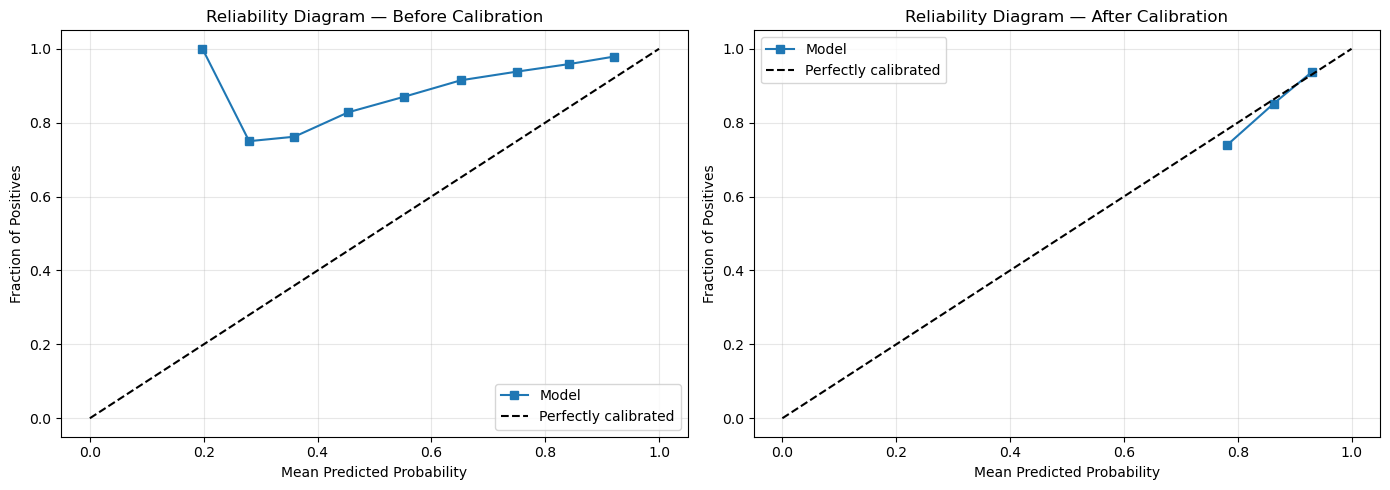

  Brier before: 0.1588
  Brier after:  0.0868


In [109]:
print("=== Reliability Diagram ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, title in zip(axes, [oof_proba, oof_proba_calibrated], ['Before Calibration', 'After Calibration']):
    fraction_of_positives, mean_predicted_value = calibration_curve(y_model, proba, n_bins=10)
    ax.plot(mean_predicted_value, fraction_of_positives, "s-", label="Model")
    ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"Reliability Diagram — {title}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"  Brier before: {brier_before:.4f}")
print(f"  Brier after:  {brier_after:.4f}")


In [112]:
from sklearn.metrics import (
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    f1_score,
    recall_score
)

In [113]:
print("=== Evaluation Multi-Metrik (at best threshold) ===")

# Evaluate at BEST threshold, not 0.5
y_pred_best = (oof_proba_calibrated >= best_thresh).astype(int)

eval_metrics = {
    'pr_auc': average_precision_score(y_model, oof_proba_calibrated),
    'mcc': matthews_corrcoef(y_model, y_pred_best),
    'balanced_accuracy': balanced_accuracy_score(y_model, y_pred_best),
    'macro_f1': f1_score(y_model, y_pred_best, average='macro'),
    'f1_minority': f1_score(y_model, y_pred_best, pos_label=0),
    'f1_majority': f1_score(y_model, y_pred_best, pos_label=1),
    'recall_minority': recall_score(y_model, y_pred_best, pos_label=0),
    'recall_majority': recall_score(y_model, y_pred_best, pos_label=1),
}

print(f"\n  Best threshold used: {best_thresh:.2f}")
print(f"  Predicted distribution: {(y_pred_best==1).sum()} pos, {(y_pred_best==0).sum()} neg")
print(f"  Actual distribution: {y_model.sum()} pos, {len(y_model)-y_model.sum()} neg")

print("\n" + "=" * 70)
print("  MODEL vs DUMMY BASELINE (at best threshold)")
print("=" * 70)
print(f"  {'Metric':25s} {'Dummy':>10s} {'Model':>10s} {'Improvement':>12s}")
print(f"  {'-'*70}")
for metric in ['pr_auc', 'mcc', 'balanced_accuracy', 'macro_f1']:
    dummy_val = dummy_metrics[metric]
    model_val = eval_metrics[metric]
    improvement = model_val - dummy_val
    print(f"  {metric:25s} {dummy_val:10.4f} {model_val:10.4f} {improvement:+12.4f}")
print("=" * 70)

print(f"\n  Per-class breakdown:")
print(f"    Minority (Tidak Sesuai): F1={eval_metrics['f1_minority']:.4f}, Recall={eval_metrics['recall_minority']:.4f}")
print(f"    Majority (Sesuai):      F1={eval_metrics['f1_majority']:.4f}, Recall={eval_metrics['recall_majority']:.4f}")


=== Evaluation Multi-Metrik (at best threshold) ===

  Best threshold used: 0.90
  Predicted distribution: 8700 pos, 5697 neg
  Actual distribution: 12960 pos, 1437 neg

  MODEL vs DUMMY BASELINE (at best threshold)
  Metric                         Dummy      Model  Improvement
  ----------------------------------------------------------------------
  pr_auc                        0.9002     0.9429      +0.0427
  mcc                           0.0000     0.1537      +0.1537
  balanced_accuracy             0.5000     0.6254      +0.1254
  macro_f1                      0.4737     0.5017      +0.0280

  Per-class breakdown:
    Minority (Tidak Sesuai): F1=0.2504, Recall=0.6214
    Majority (Sesuai):      F1=0.7531, Recall=0.6293


=== Threshold Tuning ===
  Best threshold: 0.84
  Macro F1 at best threshold: 0.5733


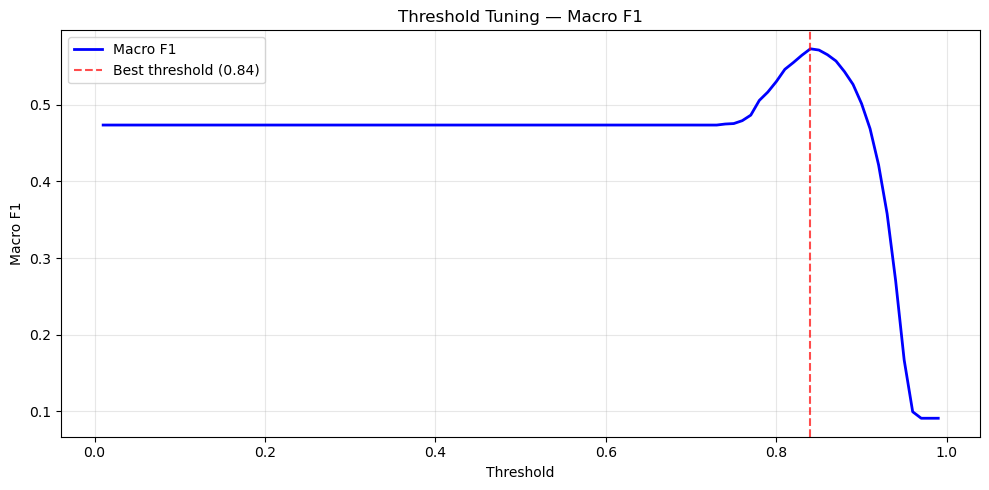

In [114]:
print("=== Threshold Tuning ===")

thresholds = np.arange(0.01, 1.00, 0.01)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (oof_proba_calibrated >= thresh).astype(int)
    f1_m = f1_score(y_model, y_pred_thresh, average='macro')
    threshold_results.append({'threshold': thresh, 'macro_f1': f1_m})

thresh_df = pd.DataFrame(threshold_results)
best_thresh = thresh_df.loc[thresh_df['macro_f1'].idxmax(), 'threshold']
best_f1 = thresh_df['macro_f1'].max()

print(f"  Best threshold: {best_thresh:.2f}")
print(f"  Macro F1 at best threshold: {best_f1:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['macro_f1'], 'b-', lw=2, label='Macro F1')
ax.axvline(x=best_thresh, color='red', linestyle='--', alpha=0.7, label=f'Best threshold ({best_thresh:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Macro F1')
ax.set_title('Threshold Tuning — Macro F1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [115]:
print("=== Evaluation Multi-Metrik (at best threshold) ===")

# Evaluate at BEST threshold
y_pred_best = (oof_proba_calibrated >= best_thresh).astype(int)

eval_metrics = {
    'pr_auc': average_precision_score(y_model, oof_proba_calibrated),
    'mcc': matthews_corrcoef(y_model, y_pred_best),
    'balanced_accuracy': balanced_accuracy_score(y_model, y_pred_best),
    'macro_f1': f1_score(y_model, y_pred_best, average='macro'),
    'f1_minority': f1_score(y_model, y_pred_best, pos_label=0),
    'f1_majority': f1_score(y_model, y_pred_best, pos_label=1),
    'recall_minority': recall_score(y_model, y_pred_best, pos_label=0),
    'recall_majority': recall_score(y_model, y_pred_best, pos_label=1),
}

print(f"\n  Best threshold used: {best_thresh:.2f}")
print(f"  Predicted distribution: {(y_pred_best==1).sum()} pos, {(y_pred_best==0).sum()} neg")
print(f"  Actual distribution: {y_model.sum()} pos, {len(y_model)-y_model.sum()} neg")

print("\n" + "=" * 70)
print("  MODEL vs DUMMY BASELINE (at best threshold)")
print("=" * 70)
print(f"  {'Metric':25s} {'Dummy':>10s} {'Model':>10s} {'Improvement':>12s}")
print(f"  {'-'*70}")
for metric in ['pr_auc', 'mcc', 'balanced_accuracy', 'macro_f1']:
    dummy_val = dummy_metrics[metric]
    model_val = eval_metrics[metric]
    improvement = model_val - dummy_val
    print(f"  {metric:25s} {dummy_val:10.4f} {model_val:10.4f} {improvement:+12.4f}")
print("=" * 70)

print(f"\n  Per-class breakdown:")
print(f"    Minority (Tidak Sesuai): F1={eval_metrics['f1_minority']:.4f}, Recall={eval_metrics['recall_minority']:.4f}")
print(f"    Majority (Sesuai):      F1={eval_metrics['f1_majority']:.4f}, Recall={eval_metrics['recall_majority']:.4f}")


=== Evaluation Multi-Metrik (at best threshold) ===

  Best threshold used: 0.84
  Predicted distribution: 12842 pos, 1555 neg
  Actual distribution: 12960 pos, 1437 neg

  MODEL vs DUMMY BASELINE (at best threshold)
  Metric                         Dummy      Model  Improvement
  ----------------------------------------------------------------------
  pr_auc                        0.9002     0.9429      +0.0427
  mcc                           0.0000     0.1469      +0.1469
  balanced_accuracy             0.5000     0.5761      +0.0761
  macro_f1                      0.4737     0.5733      +0.0996

  Per-class breakdown:
    Minority (Tidak Sesuai): F1=0.2353, Recall=0.2450
    Majority (Sesuai):      F1=0.9113, Recall=0.9072


In [117]:
print("=== Test Set Prediction ===")
t0 = time.time()

# Load test set
test_df = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/test.csv')
print(f"  Test shape: {test_df.shape}")

# Preprocessing — same pipeline as train
test_processed = preprocessor.transform(test_df)

# LSA cosine similarity
tfidf_lsa_loaded = joblib.load(os.path.join(models_dir, 'tfidf_lsa_vectorizer.joblib'))
svd_lsa_loaded = joblib.load(os.path.join(models_dir, 'svd_lsa_model.joblib'))

h_col_b = f'{headline_col}_clean_b'
a_col_b = f'{article_col}_clean_b'
all_text_test = pd.concat([test_processed[h_col_b], test_processed[a_col_b]]).astype(str)
tfidf_test = tfidf_lsa_loaded.transform(all_text_test)
lsa_test = svd_lsa_loaded.transform(tfidf_test)

n_test = len(test_processed)
lsa_h_test = lsa_test[:n_test]
lsa_a_test = lsa_test[n_test:2*n_test]
test_lsa_sim = np.array([
    cosine_similarity(lsa_h_test[i:i+1], lsa_a_test[i:i+1])[0,0]
    for i in range(n_test)
])

# Feature extraction
X_test_features = feature_pipeline.transform(test_processed)
X_test_df = pd.DataFrame(X_test_features, columns=feature_names, index=test_processed.index)
X_test_df['feat_lsa_cosine_sim'] = test_lsa_sim

# Ensure column alignment
for col in feature_cols:
    if col not in X_test_df.columns:
        X_test_df[col] = 0
X_test_df = X_test_df[feature_cols]

print(f"  Test features shape: {X_test_df.shape}")

# Predict
# Get scaler associated with the selected best model
final_scaler = zoo_models[best_model_name]['scaler']
final_model = zoo_models[best_model_name]['model']

if final_scaler is not None:
    X_test_scaled = final_scaler.transform(X_test_df)
    test_proba = final_model.predict_proba(X_test_scaled)[:, 1]
else:
    test_proba = final_model.predict_proba(X_test_df)[:, 1]
test_proba_calibrated = final_calibrator.predict_proba(test_proba.reshape(-1, 1))[:, 1]
test_pred = (test_proba_calibrated >= best_thresh).astype(int)

print(f"\n  Predicted distribution:")
print(f"    Sesuai (1): {(test_pred == 1).sum()}")
print(f"    Tidak Sesuai (0): {(test_pred == 0).sum()}")

# Save submission
submission_dir = '../submissions/01_full_v1'
os.makedirs(submission_dir, exist_ok=True)

submission = pd.DataFrame({'id': test_df['id'], 'label': test_pred})
submission_path = os.path.join(submission_dir, 'submission.csv')
submission.to_csv(submission_path, index=False)

print(f"\n  Submission saved: {submission_path}")
print(f"  Shape: {submission.shape}")
print(submission.head(10).to_string(index=False))
print(f"\n  Time: {time.time()-t0:.1f}s")

# Cleanup
del test_processed, X_test_df, tfidf_test, lsa_test, lsa_h_test, lsa_a_test
cleanup()


=== Test Set Prediction ===
  Test shape: (3603, 3)
  Test features shape: (3603, 37)

  Predicted distribution:
    Sesuai (1): 3348
    Tidak Sesuai (0): 255

  Submission saved: ../submissions/01_full_v1\submission.csv
  Shape: (3603, 2)
     id  label
te00000      0
te00001      0
te00002      1
te00003      1
te00004      1
te00005      1
te00006      1
te00007      1
te00008      1
te00009      1

  Time: 33.7s
[MEMORY after cleanup] 723.2 MB


=== Final Report ===


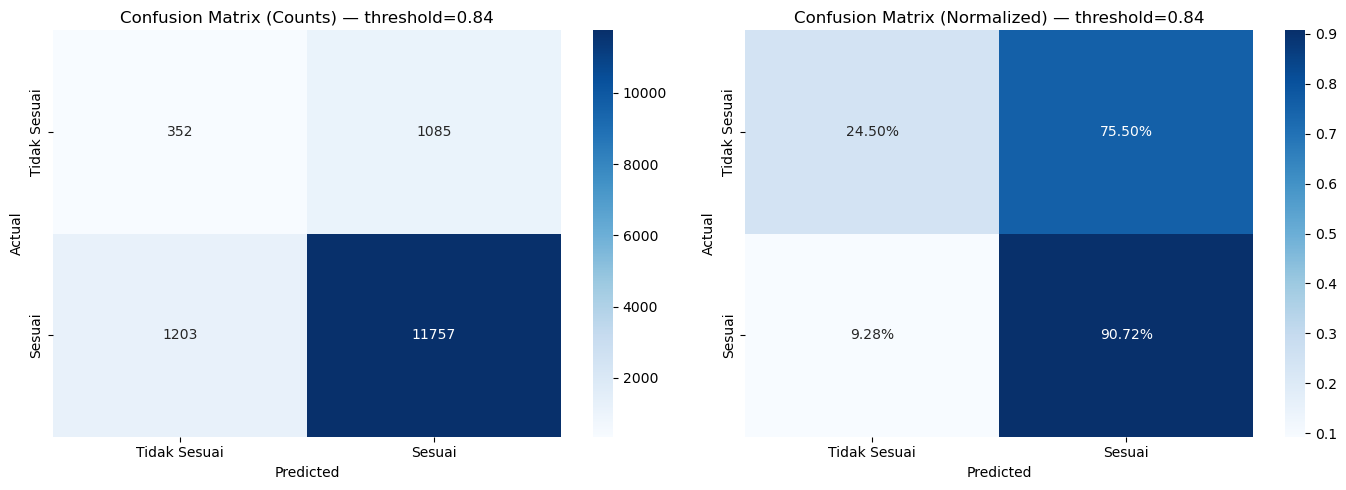

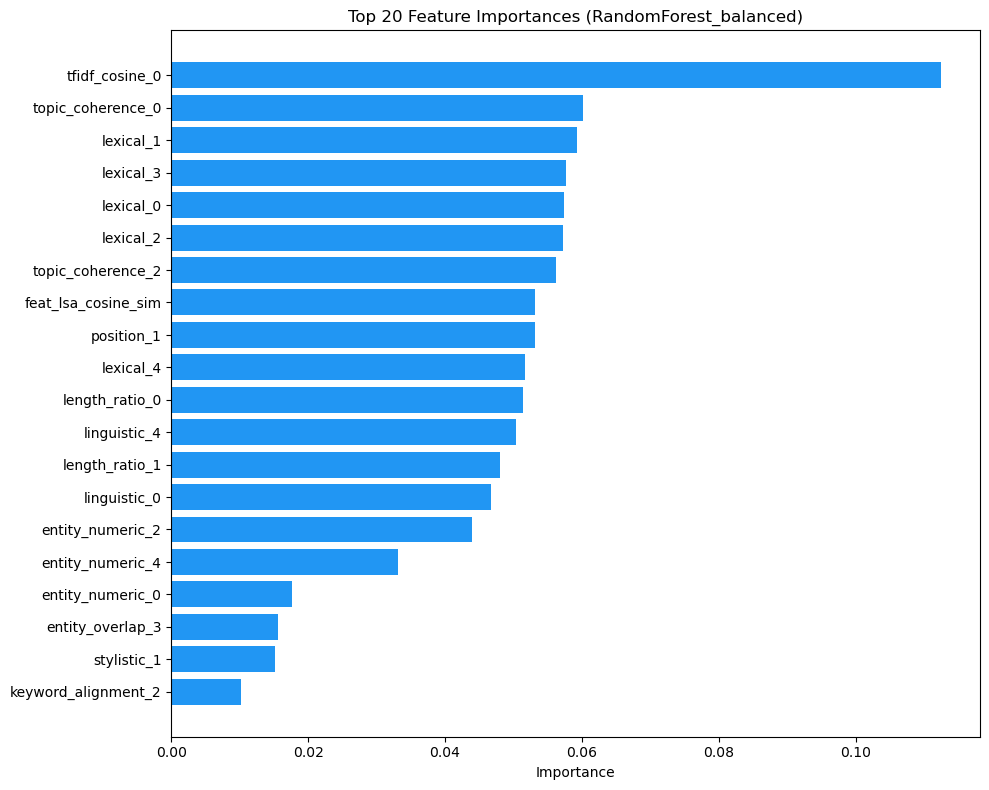


=== Model Zoo Final Comparison ===
                       macro_f1       mcc  balanced_accuracy  minority_f1
RandomForest_balanced  0.564328  0.151381           0.598412     0.253514
XGBoost                0.550849  0.137619           0.594655     0.244084
LogisticRegression     0.497364  0.153658           0.625930     0.249589
LightGBM               0.473736  0.000000           0.500000     0.000000

  FINAL COMPARISON: Previous Attempt (0.52) vs New Pipeline
           Metric  Previous  Dummy Baseline  RandomForest_balanced (OOF)
           PR-AUC      0.52        0.900188                     0.942850
              MCC      0.52        0.000000                     0.146915
Balanced Accuracy      0.52        0.500000                     0.576065
         Macro F1      0.52        0.473736                     0.573309
      Minority F1      0.52        0.000000                     0.235294

  run_log.json saved to ../data/processing/run_log.json

  DONE. Pipeline complete.
[MEMORY fi

143.87109375

In [118]:
print("=== Final Report ===")

# Confusion Matrix at best threshold
y_pred_oof = (oof_proba_calibrated >= best_thresh).astype(int)
cm = confusion_matrix(y_model, y_pred_oof)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Tidak Sesuai', 'Sesuai'],
            yticklabels=['Tidak Sesuai', 'Sesuai'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (Counts) — threshold={best_thresh:.2f}')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Tidak Sesuai', 'Sesuai'],
            yticklabels=['Tidak Sesuai', 'Sesuai'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix (Normalized) — threshold={best_thresh:.2f}')

plt.tight_layout()
plt.show()

# Feature Importance (top 20)
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
else:
    importances = np.abs(final_model.coef_[0])

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)
ax.barh(range(top_n), top_features['importance'].values, color='#2196F3')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Feature Importances ({best_model_name})')
plt.tight_layout()
plt.show()

# Model Zoo Comparison
print("\n=== Model Zoo Final Comparison ===")
zoo_final = pd.DataFrame(zoo_oof_metrics).T.sort_values('macro_f1', ascending=False)
print(zoo_final.to_string())

# Final Comparison Table
print("\n" + "=" * 70)
print("  FINAL COMPARISON: Previous Attempt (0.52) vs New Pipeline")
print("=" * 70)
comparison = {
    'Metric': ['PR-AUC', 'MCC', 'Balanced Accuracy', 'Macro F1', 'Minority F1'],
    'Previous': [0.52, 0.52, 0.52, 0.52, 0.52],
    'Dummy Baseline': [dummy_metrics['pr_auc'], dummy_metrics['mcc'],
                       dummy_metrics['balanced_accuracy'], dummy_metrics['macro_f1'], 0.0],
    f'{best_model_name} (OOF)': [
        eval_metrics['pr_auc'], eval_metrics['mcc'],
        eval_metrics['balanced_accuracy'], eval_metrics['macro_f1'],
        eval_metrics.get('f1_minority', 0)
    ],
}
comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))
print("=" * 70)

# Save run_log.json
run_log = {
    "run_id": "v1_2026-09-05",
    "data": {
        "n_train": int(len(train)),
        "n_test": int(len(test)),
        "label_distribution": {str(k): int(v) for k, v in train[label_col].value_counts().items()}
    },
    "preprocessing": {
        "stopword_source": "Sastrawi",
        "spacy_pipeline": "spacy.blank('id') + custom rules",
        "limitations": ["spaCy blank tidak punya POS/dependency parser native untuk id"]
    },
    "features": {
        "feature_names": feature_cols,
        "n_features": len(feature_cols)
    },
    "dummy_baseline": dummy_metrics,
    "noise_detection": noise_detection_info,
    "model_zoo": {
        "models_trained": list(zoo_oof_metrics.keys()),
        "best_model": best_model_name,
        "comparison": {k: {mk: round(mv, 4) for mk, mv in v.items()} for k, v in zoo_oof_metrics.items()}
    },
    "calibration": calibration_info,
    "threshold_tuning": {
        "best_threshold": float(best_thresh),
        "macro_f1_at_best_threshold": float(best_f1),
        "sweep_range": [0.01, 0.99]
    },
    "evaluation_oof": {k: round(v, 4) if isinstance(v, float) else v for k, v in eval_metrics.items()},
    "comparison_to_previous_attempt": {
        "previous_macro_f1": 0.52,
        "new_macro_f1": float(eval_metrics['macro_f1']),
        "improvement": float(eval_metrics['macro_f1'] - 0.52)
    }
}

with open(os.path.join(models_dir, 'run_log.json'), 'w', encoding='utf-8') as f:
    json.dump(run_log, f, indent=2, ensure_ascii=False)

print(f"\n  run_log.json saved to {models_dir}/run_log.json")
print(f"\n  DONE. Pipeline complete.")
log_memory("final")


In [86]:
print("=== DEBUG: Feature Matrix Health ===")
print(f"X_df shape: {X_df.shape}")
print(f"feature_cols count: {len(feature_cols)}")
print(f"Any NaN: {X_df.isnull().sum().sum()}")
print(f"Any Inf: {np.isinf(X_df.values).sum()}")
print(f"Min values: {X_df.min().min()}")
print(f"Max values: {X_df.max().max()}")
print(f"\nPer-column NaN count:")
nan_cols = X_df.columns[X_df.isnull().any()]
for c in nan_cols:
    print(f"  {c}: {X_df[c].isnull().sum()} NaN")


=== DEBUG: Feature Matrix Health ===
X_df shape: (14397, 27)
feature_cols count: 27
Any NaN: 0
Any Inf: 0
Min values: -0.11194330465904107
Max values: 4228.341359773372

Per-column NaN count:


In [87]:
print(f"\n=== DEBUG: OOF Predictions ===")
print(f"oof_proba min: {oof_proba.min():.4f}")
print(f"oof_proba max: {oof_proba.max():.4f}")
print(f"oof_proba mean: {oof_proba.mean():.4f}")
print(f"oof_proba std: {oof_proba.std():.4f}")
print(f"Predicted class distribution (thresh=0.5): {((oof_proba >= 0.5).astype(int)).sum()} pos, {((oof_proba < 0.5).astype(int)).sum()} neg")
print(f"Actual class distribution: {y_model.sum()} pos, {len(y_model) - y_model.sum()} neg")



=== DEBUG: OOF Predictions ===
oof_proba min: 0.8323
oof_proba max: 0.9129
oof_proba mean: 0.8815
oof_proba std: 0.0149
Predicted class distribution (thresh=0.5): 14397 pos, 0 neg
Actual class distribution: 12960 pos, 1437 neg


In [88]:
print(f"\n=== DEBUG: Model Per-Fold ===")
for i, model in enumerate(models_per_fold):
    preds = model.predict(X_model)
    print(f"  Fold {i}: {preds.sum()} pos / {len(preds)} total ({preds.mean()*100:.1f}%)")


=== DEBUG: Model Per-Fold ===
  Fold 0: 14397 pos / 14397 total (100.0%)
  Fold 1: 14397 pos / 14397 total (100.0%)
  Fold 2: 14397 pos / 14397 total (100.0%)
  Fold 3: 14397 pos / 14397 total (100.0%)
  Fold 4: 14397 pos / 14397 total (100.0%)


In [89]:
print("=== DEBUG: overlap_coeff_b per label ===")
for lbl in [0, 1]:
    subset = X_df.loc[y_model == lbl, 'lexical_3']
    print(f"  Label {lbl} ({label_names[lbl]}): mean={subset.mean():.4f}, std={subset.std():.4f}, min={subset.min():.4f}, max={subset.max():.4f}")

# Check if this feature alone can perfectly separate classes
from sklearn.metrics import roc_auc_score
leak_auc = roc_auc_score(y_model, X_df['lexical_3'])
print(f"\n  lexical_3 alone AUC: {leak_auc:.4f}")
print(f"  NOTE: If AUC > 0.85, this feature may be leaking label information")

=== DEBUG: overlap_coeff_b per label ===
  Label 0 (Tidak Sesuai): mean=0.7297, std=0.1412, min=0.1429, max=1.0000
  Label 1 (Sesuai): mean=0.7852, std=0.1469, min=0.0000, max=1.0000

  lexical_3 alone AUC: 0.6153
  NOTE: If AUC > 0.85, this feature may be leaking label information
